# Project Setup

Import Required Libraries

In [ ]:
# Import libraries

# For Colab
import gdown
from google.colab import drive

# For data analysis
import numpy as np
import pandas as pd
import polars as pl
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns
from yellowbrick.cluster import KElbowVisualizer, SilhouetteVisualizer
from yellowbrick.cluster.elbow import kelbow_visualizer
%matplotlib inline

# For garbage collection
import gc

# Regression
from xgboost import XGBRegressor
from sklearn.linear_model import ElasticNet, ElasticNetCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, train_test_split, StratifiedKFold
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score
from sklearn.model_selection import KFold

# Model evaluation tools
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import shap

Load raw data for demographics and household spending

In [ ]:
# Mount Google Drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [ ]:
# Confirm files are in the expected path
!ls "/content/drive/My Drive/DS3000/coursework_data"

DemoStats.csv  HouseholdSpend.csv


In [ ]:
# Original file locations for A.B.
demo_data = pl.read_csv("/content/drive/My Drive/DS3000/coursework_data/DemoStats.csv", null_values = "NA").sample(fraction = 0.1, seed = 2025)
household_data = pl.read_csv("/content/drive/My Drive/DS3000/coursework_data/HouseholdSpend.csv", null_values = "NA").sample(fraction = 0.1, seed = 2025)

# For local work
# demo_data = pl.read_csv("D:\\ds_3000_project\\DemoStats.csv", null_values = "NA").sample(fraction = 0.1, seed = 2025)
# household_data = pl.read_csv("D:\\ds_3000_project\\HouseholdSpend.csv", null_values = "NA").sample(fraction = 0.1, seed = 2025)

Preview Initial Dataset Dimensions

In [ ]:
print(f"demo_data shape: {demo_data.shape}")
print(f"household_data shape: {household_data.shape}")

demo_data shape: (86897, 736)
household_data shape: (86897, 246)


# Data Cleaning & Preparation

Drop zero-only rows (Household)

In [ ]:
###
#
# Cleaning out all zero only rows
# DemoStats data has no rows that have 0s
#
###

# Convert Househould Data into pandas since we are checking by rows
household_data = household_data.to_pandas()

# Select only numeric columns
household_numeric_data = household_data.select_dtypes(include='number')

# Create a boolean mask for rows where all numeric columns equal 0
house_mask = (household_numeric_data == 0).all(axis=1)

# Count the rows that are only zeros
house_zero_row_count = house_mask.sum()
print("Household Rows with only zeros:", house_zero_row_count)

# Remove the rows: use mask.values (a 1D numpy array) for indexing
household_data = household_data.loc[house_mask.values == False]

# Optional: reset the index
household_data = household_data.reset_index(drop=True)

# Convert Household Data back to polars
household_data = pl.from_pandas(household_data)

# Deleting unnecessary variables
# del [household_numeric_data, house_mask, house_zero_row_count]
del household_numeric_data, house_mask, house_zero_row_count

# Trigger Garbage Collection
gc.collect()

Household Rows with only zeros: 9140


30

Make sure 0-filled rows were removed (Household)

In [ ]:
# Convert again to pandas for checking
household_data_check = household_data.to_pandas()

# Select numeric columns
numeric_check = household_data_check.select_dtypes(include='number')

# Check if any rows are still entirely zero
remaining_zeros = (numeric_check == 0).all(axis=1).sum()
print("Remaining zero-only rows after cleanup:", remaining_zeros)

# Cleanup variables
del household_data_check, numeric_check, remaining_zeros
gc.collect()

Remaining zero-only rows after cleanup: 0


0

Drop zero-only rows (Demographics)

In [ ]:
###
#
# Cleaning out all zero only rows (Demographics dataset)
#
###

# Convert Househould Data into pandas since we are checking by rows
demo_data = demo_data.to_pandas()

# Select only numeric columns
demo_numeric_data = demo_data.select_dtypes(include='number')

# Create a boolean mask for rows where all numeric columns equal 0
demo_mask = (demo_numeric_data == 0).all(axis=1)

# Count the rows that are only zeros
demo_zero_row_count = demo_mask.sum()
print("Demographic Rows with only zeros:", demo_zero_row_count)

# Remove the rows: use mask.values (a 1D numpy array) for indexing
demo_data = demo_data.loc[demo_mask.values == False]

# Optional: reset the index
demo_data = demo_data.reset_index(drop=True)

# Convert Household Data back to polars
demo_data = pl.from_pandas(demo_data)

# Deleting unnecessary variables
# del [household_numeric_data, house_mask, house_zero_row_count]
del demo_numeric_data, demo_mask, demo_zero_row_count

# Trigger Garbage Collection
gc.collect()

Demographic Rows with only zeros: 0


0

In [ ]:
# Convert again to pandas for checking
demo_data_check = demo_data.to_pandas()

# Select numeric columns
numeric_check = demo_data_check.select_dtypes(include='number')

# Check if any rows are still entirely zero
remaining_zeros = (numeric_check == 0).all(axis=1).sum()
print("Remaining zero-only rows after cleanup:", remaining_zeros)

# Cleanup variables
del demo_data_check, numeric_check, remaining_zeros
gc.collect()

Remaining zero-only rows after cleanup: 0


0

Checking dataset dimensions again

In [ ]:
household_data.shape

(77757, 246)

In [ ]:
# Note that demographics data has more columns than household data
# # I don't think an observation is useful if demographics data was present but household data was 0-filled
demo_data.shape

(86897, 736)

Look at the first few rows of the household data

In [ ]:
household_data.head()

CODE,GEO,HSBASHHD,HSHNIAGG,HSAGDISPIN,HSAGDISCIN,HSTT001,HSTE001,HSTX001,HSTC001,HSSH001S,HSFD001S,HSHO001S,HSHC001S,HSHF001S,HSTR001S,HSRE001S,HSPC001S,HSCL001S,HSED002S,HSRO001S,HSTA001S,HSGC001S,HSME001S,HSEP001S,HSMG001S,HSTE001ZBS,HSWH002S,HSWH028S,HSWH040S,HSWH041S,HSWH042S,HSSH001,HSSH002,HSSH003,HSSH004,HSSH053,…,HSTR002,HSTR003,HSTR004,HSTR005,HSTR006,HSTR007,HSTR008,HSTR009,HSTR058,HSTR010,HSTR011,HSTR012,HSTR014M,HSTR015,HSTR020,HSTR030,HSTR031,HSTR032,HSTR033,HSTR034,HSTR035,HSTR036,HSTR037,HSTR038,HSTR039,HSTR040,HSTR041,HSTR050,HSTR051,HSTR052,HSTR053,HSTR054,HSTR055,HSTR056,HSTR056A,HSTR056B,HSTR057
str,str,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""K2J0E5""","""FSALDU""",34,7.2926e6,5.2158e6,3.6438e6,8.4555e6,7.3284e6,1.5898e6,5.0940e6,1.3117e6,830774.695414,340593.8197,314138.489079,277733.883155,895217.624308,297428.704352,149347.856698,179998.0783,100028.895208,12811.8937,212945.731167,82411.233623,88832.190691,462842.556274,181763.930135,1.1271e6,184235.490998,10609.19457,876189.65977,36100.340837,20010.942777,1.3117e6,1.0555e6,150203.434427,147492.383056,145935.491787,…,813730.439565,457873.649936,448781.492018,66062.981584,31909.195406,350809.315027,544.745039,441.932176,102.812863,8547.412879,7588.710976,4544.605239,3044.105736,958.701904,4952.339751,350904.449878,3031.405984,22266.020576,32396.714585,55795.025209,801.546475,204004.572513,18094.009938,11990.518544,2524.636055,553.151348,1971.484707,81487.184743,9765.413782,4196.32405,771.226475,59439.068701,105.835075,2062.421888,419.489352,1642.932536,5146.894773
"""K1S3Y6""","""FSALDU""",5,1.0103e6,695629.298505,505149.395812,1.0350e6,1.0026e6,251588.077205,653501.70312,166689.761772,109202.120045,45938.715765,39142.075705,29352.100959,103170.829239,38036.657211,19333.552977,23374.776192,16812.416902,1772.770093,38194.387341,7675.734774,14805.804146,61407.823139,36067.195559,32451.062119,19911.784031,1555.650982,524.998359,6924.650988,3533.977759,166689.761772,127069.320103,42076.505236,41590.578042,41072.350865,…,86710.635241,48065.392762,46721.273624,11015.256967,5943.157923,29762.858734,77.790884,44.178602,33.612282,1266.328254,1083.605113,818.047259,265.557855,182.723141,940.666796,37704.575684,365.521209,3116.190824,6200.950962,3649.639635,62.572565,19293.406107,2129.662025,2508.75569,377.876666,81.388241,296.488425,16460.193999,2678.935858,1626.806907,69.552331,10762.537199,37.362334,531.884082,110.725619,421.158463,753.115288
"""G1M3X1""","""FSALDU""",7,510969.961214,424930.91738,311663.139861,398926.811779,478625.191443,55717.422789,388890.078823,70480.999136,77482.952125,24092.390998,40832.59818,10591.293353,70510.245637,17675.427052,13013.543404,19220.641951,6106.939112,1261.82829,24424.147603,4599.973776,8597.098206,29923.805614,4093.884218,-79698.379663,23.373037,243.795609,-85862.325315,2766.346885,3130.43012,70480.999136,58145.80051,55691.394847,54536.80474,54493.932477,…,63800.061104,29371.362148,27942.858204,8420.596933,1732.532201,17789.72907,22.837214,10.333666,12.503547,1405.666731,1381.376383,1210.903074,170.473309,24.290348,249.062803,34179.636154,1012.821477,3274.972121,3869.097294,8333.995345,7.635348,13976.18597,1036.591189,1695.873117,972.464292,387.626908,584.837385,6710.184532,2273.135713,459.461853,128.6107,3315.479048,63.5827,180.185088,49.873456,130.311632,289.72943
"""L3P7J5""","""FSALDU""",10,1.6930e6,1.2679e6,908376.66869,2.3780e6,1.5933e6,372538.77505,1.1124e6,325390.091294,177856.212387,73686.788162,75070.643293,53213.938641,172115.555791,56335.15271,24430.322707,49902.739153,42774.288813,1058.035018,22930.234892,13126.34115,24493.109286,56218.588543,52146.88418,784749.070116,173712.701464,803.56752,593530.510015,8982.11454,7720.176578,325390.091295,255420.950557,14663.672

Look at the first few rows of the demographics data

In [ ]:
demo_data.head()

CODE,GEO,ECYASQKM,ECYALSQKM,ECYBASPOP,ECYBASHHD,ECYBASHPOP,ECYBAS12P,ECYBAS15P,ECYBAS18P,ECYBAS19P,ECYBAS12HP,ECYBAS15HP,ECYBAS18HP,ECYBAS19HP,ECYBASTNGH,ECYBASADUH,ECYBASCF,ECYBASCFH,ECYBASKID,ECYBASLF,ECYPTAPOP,ECYPTA_0_4,ECYPTA_5_9,ECYPTA1014,ECYPTA1519,ECYPTA2024,ECYPTA2529,ECYPTA3034,ECYPTA3539,ECYPTA4044,ECYPTA4549,ECYPTA5054,ECYPTA5559,ECYPTA6064,ECYPTA6569,ECYPTA7074,…,ECYRIMINDI,ECYRIMNEPA,ECYRIMPAKI,ECYRIMSRI,ECYRIMSASO,ECYRIMOCE,ECYRIMAUSS,ECYRIMOCEO,ECYPIMHPOP,ECYPIMNI,ECYPIMIM,ECYPIMP01,ECYPIM0110,ECYPIM1115,ECYPIM1621,ECYPIM22CY,ECYPIMNPER,ECYAIMHPOP,ECYAIMNI,ECYAIMIM,ECYAIM_0_5,ECYAIM_514,ECYAIM1524,ECYAIM2544,ECYAIM45P,ECYAIMNPER,ECYGENHPOP,ECYGEN1GEN,ECYGEN2GEN,ECYGEN3GEN,ECYTCAHPOP,ECYTCACIT,ECYTCA_U18,ECYTCA_18P,ECYNCANCIT,ECYNCA_U18,ECYNCA_18P
str,str,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,…,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64
"""K2J0E5""","""FSALDU""",0,0,113,34,113,95,87,81,79,96,87,81,79,15,56,31,29,42,71,113,5,8,13,10,6,4,5,5,10,11,10,6,5,5,4,…,3,0,1,0,0,0,0,0,113,63,45,13,11,6,4,11,5,113,63,45,3,7,6,24,5,5,113,50,31,32,113,96,28,68,17,4,13
"""K1S3Y6""","""FSALDU""",0,0,13,5,13,13,12,11,10,13,12,10,10,3,7,3,3,4,8,13,0,0,1,2,2,2,1,1,0,1,1,1,0,1,0,…,0,0,0,0,0,0,0,0,13,8,2,2,0,0,0,0,3,13,8,2,0,1,0,1,0,3,13,5,2,6,13,13,3,10,0,0,0
"""G1M3X1""","""FSALDU""",0,0,13,7,13,13,13,12,12,13,13,13,13,0,8,2,2,1,9,13,0,0,0,1,0,1,0,0,1,0,2,1,3,1,1,…,0,0,0,0,0,0,0,0,13,13,0,0,0,0,0,0,0,13,13,0,0,0,0,0,0,0,13,0,0,13,13,13,0,13,0,0,0
"""L3P7J5""","""FSALDU""",0,0,36,10,36,34,32,30,28,35,32,29,29,6,17,11,9,11,17,36,0,0,4,4,1,1,3,2,2,2,3,2,2,2,2,…,0,0,0,0,0,0,0,0,36,16,19,13,4,2,0,0,1,36,16,19,1,1,6,10,1,1,36,20,13,3,36,33,7,26,3,0,3
"""L3K5B2""","""FSALDU""",0,0,20,8,20,16,15,15,15,17,15,15,15,2,10,6,6,6,10,20,1,2,2,0,2,3,2,1,1,0,1,1,1,2,0,…,0,0,0,0,0,0,0,0,20,18,2,2,0,0,0,0,0,20,18,2,0,1,1,0,0,0,20,2,2,16,20,20,5,15,0,0,0


Summarizing variable types for the household and demogaphics datasets

In [ ]:
# Summarizing the variable data types for the household dataset

# Create a dataframe with variable names and data types
column_info_df = pl.DataFrame(
    {
        "column": list(household_data.schema.keys()), # Get column names
        "data_type": [str(dtype) for dtype in household_data.schema.values()], # Get and convert data types to string
    }
)

# Get value counts for data types
column_info_df.group_by("data_type").agg(pl.len().alias("count")).sort("count", descending = True)

data_type,count
str,u32
"""Float64""",243
"""String""",2
"""Int64""",1


In [ ]:
# Summarizing the variable data types for the demographic dataset

# Create a dataframe with variable names and data types
column_info_df = pl.DataFrame(
    {
        "column": list(demo_data.schema.keys()), # Get column names
        "data_type": [str(dtype) for dtype in demo_data.schema.values()], # Get and convert data types to string
    }
)

# Get value counts for data types
column_info_df.group_by("data_type").agg(pl.len().alias("count")).sort("count", descending = True)

data_type,count
str,u32
"""Int64""",706
"""Float64""",28
"""String""",2


Inspecting the string columns

In [ ]:
# Checking out the string variables for the household dataset
# Should drop "GEO" because it's not unique to each observation
household_data.select(pl.col(pl.String)).head(5)

CODE,GEO
str,str
"""K2J0E5""","""FSALDU"""
"""K1S3Y6""","""FSALDU"""
"""G1M3X1""","""FSALDU"""
"""L3P7J5""","""FSALDU"""
"""L3K5B2""","""FSALDU"""


In [ ]:
# Checking out the string variables for the demographics dataset
# Should drop "GEO" because it's not unique to each observation
demo_data.select(pl.col(pl.String)).head(5)

CODE,GEO
str,str
"""K2J0E5""","""FSALDU"""
"""K1S3Y6""","""FSALDU"""
"""G1M3X1""","""FSALDU"""
"""L3P7J5""","""FSALDU"""
"""L3K5B2""","""FSALDU"""


Drop Uninformative String Columns

In [ ]:
# Drop the GEO columns from both datasets because they're not unique to each observation
household_data = household_data.drop("GEO")
demo_data = demo_data.drop("GEO")

Remove Zero-Filled Columns (Household)

In [ ]:
# Finding and removing 0-filled columns in the household dataset

# List to store the names of zero-only columns
zero_cols = []

# Loop over all columns, checking each if only zeros are present
# If so, append the column name to the zero_cols list
for col in household_data.columns:

    # Check if all values in this column are zero
    if (household_data[col] == 0).all():
        zero_cols.append(col)

In [ ]:
# No zero-filled columns found in the household dataset
len(zero_cols)

0

Remove Zero-Filled Columns (Demographic)

In [ ]:
# Finding and removing 0-filled columns in the demographics dataset

# Create an empty list to hold numeric column names
numeric_cols = []

# Identify numeric columns
for col, dtype in demo_data.schema.items():
    if dtype in (
        pl.Int8, pl.Int16, pl.Int32, pl.Int64,
        pl.UInt8, pl.UInt16, pl.UInt32, pl.UInt64,
        pl.Float32, pl.Float64
    ):
        numeric_cols.append(col)

# Create an empty list for zero-filled columns
zero_cols = []

# Check each numeric column for all-zero values (ignoring nulls by treating them as zero)
for col in numeric_cols:
    col_is_not_zero = demo_data.select(
        (pl.col(col).fill_null(0) != 0).any()
    ).item()

    if not col_is_not_zero:
        zero_cols.append(col)

print("Zero-filled columns:", zero_cols)


Zero-filled columns: ['ECYASQKM', 'ECYALSQKM']


In [ ]:
# Two zero-filled columns found in the demographics dataset
len(zero_cols)

2

In [ ]:
# Descriptive statistics for the zero-filled columns in the demographics dataset
# There are only 2: ECYASQKM and ECYALSQKM
# These correspond to "Total Area" and "Total Land Area", respectively
# Should probably drop them
demo_data[zero_cols].describe()

statistic,ECYASQKM,ECYALSQKM
str,f64,f64
"""count""",86897.0,86897.0
"""null_count""",0.0,0.0
"""mean""",0.0,0.0
"""std""",0.0,0.0
"""min""",0.0,0.0
"""25%""",0.0,0.0
"""50%""",0.0,0.0
"""75%""",0.0,0.0
"""max""",0.0,0.0


In [ ]:
# Drop the zero-filled columns
demo_data = demo_data.drop(zero_cols)

Remove Zero-Filled Columns (Demographic)

In [ ]:
# Finding and removing 0-filled columns in the household dataset

# Create an empty list to hold numeric column names
numeric_cols = []

# Identify numeric columns
for col, dtype in household_data.schema.items():
    if dtype in (
        pl.Int8, pl.Int16, pl.Int32, pl.Int64,
        pl.UInt8, pl.UInt16, pl.UInt32, pl.UInt64,
        pl.Float32, pl.Float64
    ):
        numeric_cols.append(col)

# Create an empty list for zero-filled columns
zero_cols = []

# Check each numeric column for all-zero values (ignoring nulls by treating them as zero)
for col in numeric_cols:
    col_is_not_zero = household_data.select(
        (pl.col(col).fill_null(0) != 0).any()
    ).item()

    if not col_is_not_zero:
        zero_cols.append(col)

print("Zero-filled columns:", zero_cols)


Zero-filled columns: []


Handle Negative Values:

For the household dataset

In [ ]:
# Find the columns that contain negative values
has_negatives = []

for index, col in enumerate(household_data.columns):
  if (household_data.dtypes[index] == pl.Int64 or household_data.dtypes[index] == pl.Float64):
    minValue = household_data[col].min()
    if (minValue < 0):
      has_negatives.append(col)

print(f"The number of columns that have negative values is: {len(has_negatives)}.\n\nThese columns are:")

for entry in has_negatives:
  print(f"{entry}")

The number of columns that have negative values is: 5.

These columns are:
HSTT001
HSTE001ZBS
HSWH040S
HSWH041S
HSWH042S


In [ ]:
# Inspecting the columns that contain negative values, identified above

# Subset the dataframe to only columns with negative values
negatives_df = household_data.select(has_negatives)

# Total number of observations (rows) in the dataset
total_rows = household_data.height

# Count negative values and compute proportion for each column
for col in has_negatives:
    count = negatives_df.filter(negatives_df[col] < 0).height
    proportion = count / total_rows
    print(f"Column '{col}' has {count} negative values ({proportion:.2%} of all observations).")

# HSTT001: Total expenditure
# HSTE001ZBS: Total non-current consumption
# HSWH040S: Net purchase price of owned residences
# HSWH041S: Net purchase price of owned secondary residences
# HSWH042S: Net purchase price of other owned properties

Column 'HSTT001' has 4 negative values (0.01% of all observations).
Column 'HSTE001ZBS' has 16416 negative values (21.11% of all observations).
Column 'HSWH040S' has 25649 negative values (32.99% of all observations).
Column 'HSWH041S' has 1521 negative values (1.96% of all observations).
Column 'HSWH042S' has 1934 negative values (2.49% of all observations).


In [ ]:
# Descriptive stats for columns with negative values
household_data[has_negatives].describe()

statistic,HSTT001,HSTE001ZBS,HSWH040S,HSWH041S,HSWH042S
str,f64,f64,f64,f64,f64
"""count""",77757.0,77757.0,77757.0,77757.0,77757.0
"""null_count""",0.0,0.0,0.0,0.0,0.0
"""mean""",2.6948e6,232839.920246,124885.443522,16996.140041,10189.753264
"""std""",9.6452e6,1.2534e6,891738.460976,55536.437705,39499.29851
"""min""",-15614.406673,-1.0166e7,-1.2891e7,-26676.98553,-95861.635223
"""25%""",456925.175392,6388.544693,-10649.787891,2576.603808,1725.886169
"""50%""",1.1684e6,71446.236143,31791.09365,7101.480973,4531.969941
"""75%""",2.7509e6,258331.266485,163511.592538,17064.676864,10483.681698
"""max""",6.9634e8,1.1339e8,8.2202e7,4.3691e6,3.2145e6


For the demographics dataset (no columns containing negative values found):

In [ ]:
# Find the columns that contain negative values for the demographics dataset
# None were found
has_negatives = []

for index, col in enumerate(demo_data.columns):
  if (demo_data.dtypes[index] == pl.Int64 or demo_data.dtypes[index] == pl.Float64):
    minValue = demo_data[col].min()
    if (minValue < 0):
      has_negatives.append(col)

print(f"The number of columns that have negative values is: {len(has_negatives)}.\n\nThese columns are:")

for entry in has_negatives:
  print(f"{entry}")

The number of columns that have negative values is: 0.

These columns are:


Handle Missing Values (Household data)

In [ ]:
# Checking out missing values in the household dataset

# Make a df with var names in one column, and null counts in the next column
missing_values_df = (
    household_data.select(
        [pl.col(col).is_null().sum().alias(col) for col in household_data.columns] # Count nulls per column
    )
    .transpose(include_header = True) # Convert column names to a single column
    .rename({"column_0": "missing_count"}) # Rename output
    .with_columns([
        pl.col("missing_count").cast(pl.Int64), # Ensure numeric type
        (pl.col("missing_count") / household_data.height).alias("proportion_of_obs_missing")
        ])
    .sort("missing_count", descending = True) # Sort by missing count
)

# Show only variables with missing values
missing_values_df.filter(pl.col("missing_count") > 0)

# Seems there are no missing values in the household dataset now


column,missing_count,proportion_of_obs_missing
str,i64,f64


Handle Missing Values (Demographics data)

In [ ]:
# Checking out missing values in the demographics dataset

# Make a df with var names in one column, and null counts in the next column
missing_values_df = (
    demo_data.select(
        [pl.col(col).is_null().sum().alias(col) for col in demo_data.columns] # Count nulls per column
    )
    .transpose(include_header = True) # Convert column names to a single column
    .rename({"column_0": "missing_count"}) # Rename output
    .with_columns([
        pl.col("missing_count").cast(pl.Int64), # Ensure numeric type
        (pl.col("missing_count") / demo_data.height).alias("proportion_of_obs_missing")
        ])
    .sort("missing_count", descending = True) # Sort by missing count
)

# Show only variables with missing values
missing_values_df.filter(pl.col("missing_count") > 0)

# Found 7 columns with missing values, all have 10% or greater missing


column,missing_count,proportion_of_obs_missing
str,i64,f64
"""ECYHFAMED""",13649,0.157071
"""ECYPFAMED""",13056,0.150247
"""ECYHMAMED""",10055,0.115712
"""ECYPMAMED""",9542,0.109808
"""ECYHTAMED""",9140,0.105182
"""ECYMTNMED""",9140,0.105182
"""ECYPTAMED""",8630,0.099313


In [ ]:
demo_data.shape

(86897, 733)

In [ ]:
# Make a list of columns to drop.
# We should discuss whether to impute these values instead.

# However if I remember correctly we should only impute if missing values
# make up less than 1-2% of the column? This is at least 10% missing.

cols_to_drop = (
    missing_values_df
    .filter(pl.col("missing_count") > 0) # Keep only vars with missing values
    .select("column") # Select the column that contains column name strings
    .to_series() # Convert to Polars Series
    .to_list() # Convert to list
)

In [ ]:
# Show cols to drop
demo_data[cols_to_drop].describe()

statistic,ECYHFAMED,ECYPFAMED,ECYHMAMED,ECYPMAMED,ECYHTAMED,ECYMTNMED,ECYPTAMED
str,f64,f64,f64,f64,f64,f64,f64
"""count""",73248.0,73841.0,76842.0,77355.0,77757.0,77757.0,78267.0
"""null_count""",13649.0,13056.0,10055.0,9542.0,9140.0,9140.0,8630.0
"""mean""",44.233311,44.841802,41.850834,42.239332,42.138557,54.096839,42.641692
"""std""",14.40301,14.93201,10.894209,11.391654,10.469909,12.554452,11.105895
"""min""",2.2,2.2,2.2,2.2,15.0,19.4,15.0
"""25%""",35.0,35.0,35.0,35.0,35.0,46.5,35.4
"""50%""",42.5,42.5,40.0,40.0,41.1,55.0,41.3
"""75%""",52.5,52.8,47.5,47.5,47.7,61.6,48.3
"""max""",90.2,90.2,90.2,90.2,90.2,87.1,90.2


In [ ]:
# Drop the columns with missing values
demo_data = demo_data.drop(cols_to_drop)

# Merge Datasets
- Merge cleaned demographic and household data on the CODE identifier.

In [ ]:
# Merging
merged_data = household_data.join(demo_data, on = "CODE", how = "left")

# Delete unneeded objects
del demo_data, household_data

# Trigger garbage collection
gc.collect()

0

In [ ]:
# Note that the number of rows is the same as the household data
merged_data.shape

(77757, 970)

# Train/Test Split

In [ ]:
# Split merged_data_clustering into training, validation, and testing sets

# Set the seed and fractions for reproducibility
split_seed = 2025
train_frac = 0.7
val_frac = 0.15

# Randomly shuffle the rows with seed
shuffled = merged_data.sample(fraction=1.0, with_replacement=False, seed=split_seed)

# Calculate the indices for where the splits happen
total_rows = shuffled.height
train_index = int(total_rows * train_frac)
val_index = train_index + int(total_rows * val_frac)

# Slice the shuffled dataframe into train, validation, and test sets
train_df = shuffled[:train_index]
val_df = shuffled[train_index:val_index]
test_df = shuffled[val_index:]

# Show subset dimensions
print(f"Training set shape: {train_df.shape}")
print(f"Validation set shape: {val_df.shape}")
print(f"Testing set shape: {test_df.shape}")


Training set shape: (54429, 970)
Validation set shape: (11663, 970)
Testing set shape: (11665, 970)


Check for constant columns

In [ ]:
# Columns with standard deviation of 0 (only numeric columns)
zero_std_columns = [
    col for col in train_df.columns
    if train_df.schema[col] in (pl.Int8, pl.Int16, pl.Int32, pl.Int64,
                          pl.UInt8, pl.UInt16, pl.UInt32, pl.UInt64,
                          pl.Float32, pl.Float64)
    and train_df.select(pl.std(col)).item() == 0
]

# Columns that are of type string
string_columns = [
    col for col, dtype in train_df.schema.items()
    if dtype == pl.Utf8
]

print("Columns with standard deviation of 0:", zero_std_columns)
print("Columns of type string:", string_columns)

Columns with standard deviation of 0: []
Columns of type string: ['CODE']


# Outlier Handling

## Define and Apply Z-Score Outlier Cleaning on Train Set
- Replace low-percentage outliers with medians.

In [ ]:
# Modified version of Joel's outlier cleaning function
# Also returns dicts that contain the columns medians, and a dict with columns means and stdevs that are required for processing the test dataframe

def z_score_cleaning(df, numeric_cols, THRESHOLD_PERCENTAGE):
    columns_with_many_outliers = {}
    column_medians = {}
    column_stats = {}

    print("Initializing Cleaning")
    for col in numeric_cols:
        stats = df.select([
            pl.col(col).mean().alias("mean"),
            pl.col(col).std().alias("std"),
            pl.col(col).median().alias("median")
        ]).row(0)

        col_mean, col_std, col_median = stats
        column_medians[col] = col_median
        column_stats[col] = (col_mean, col_std)

        lower_bound = col_mean - 2.5 * col_std
        upper_bound = col_mean + 2.5 * col_std

        outlier_mask = (pl.col(col) < lower_bound) | (pl.col(col) > upper_bound)

        outlier_count = df.filter(outlier_mask).height
        outlier_percentage = (outlier_count / df.height) * 100

        if outlier_percentage < THRESHOLD_PERCENTAGE:
            df = df.with_columns([
                pl.when(outlier_mask)
                  .then(col_median)
                  .otherwise(pl.col(col))
                  .alias(col)
            ])
        else:
            columns_with_many_outliers[col] = df.filter(outlier_mask)

    print("Cleaning has concluded")
    return df, columns_with_many_outliers, column_medians, column_stats

In [ ]:
# Function that applies the medians calculated above (on the training data) to the test data outliers

def apply_medians_to_test(df_test, column_medians, column_stats):
    """
    Applies median replacement to the test dataframe using training data medians and stats.

    Arguments:
        df_test (pl.DataFrame): The test DataFrame.
        column_medians (dict): Dictionary of medians from training data.
        column_stats (dict): Dictionary of (mean, std) tuples from training data.

    Returns:
        pl.DataFrame: Cleaned test DataFrame.
    """
    for col in column_medians:
        col_median = column_medians[col]
        col_mean, col_std = column_stats[col]

        lower_bound = col_mean - 2.5 * col_std
        upper_bound = col_mean + 2.5 * col_std

        outlier_mask = (pl.col(col) < lower_bound) | (pl.col(col) > upper_bound)

        # Replace outliers with the training median
        df_test = df_test.with_columns([
            pl.when(outlier_mask)
              .then(col_median)
              .otherwise(pl.col(col))
              .alias(col)
        ])

    return df_test


In [ ]:
train_df_numeric_cols = [col for col, dtype in train_df.schema.items()
                if dtype in (pl.Int64, pl.Float64, pl.Int32, pl.Float32)]

## Clean Test Set Using Train Medians

In [ ]:
THRESHOLD_PERCENTAGE = 5.0

# Clean training data and extract medians + stats
df_train_cleaned, outliers_dict, medians_dict, stats_dict = z_score_cleaning(train_df, train_df_numeric_cols, THRESHOLD_PERCENTAGE)

Initializing Cleaning
Cleaning has concluded


Check for constant columns

In [ ]:
# Columns with standard deviation of 0 (only numeric columns)
zero_std_columns = [
    col for col in df_train_cleaned.columns
    if df_train_cleaned.schema[col] in (pl.Int8, pl.Int16, pl.Int32, pl.Int64,
                          pl.UInt8, pl.UInt16, pl.UInt32, pl.UInt64,
                          pl.Float32, pl.Float64)
    and df_train_cleaned.select(pl.std(col)).item() == 0
]

# Columns that are of type string
string_columns = [
    col for col, dtype in df_train_cleaned.schema.items()
    if dtype == pl.Utf8
]

print("Columns with standard deviation of 0:", zero_std_columns)
print("Columns of type string:", string_columns)

Columns with standard deviation of 0: ['ECYMOTCROA', 'ECYMOTCREO', 'ECYMOTCZEC', 'ECYHOMCHIN', 'ECYHOMUKRA', 'ECYHOMDUTC', 'ECYHOMHUNG', 'ECYHOMCROA', 'ECYHOMCREO', 'ECYHOMSERB', 'ECYHOMJAPA', 'ECYHOMCZEC', 'ECYHOMMNON', 'ECYTIMONAM', 'ECYTIMCUBA', 'ECYTIMCHIL', 'ECYTIMPERU', 'ECYTIMVENE', 'ECYTIMCZEC', 'ECYTIMHUNG', 'ECYTIMMOLD', 'ECYTIMIREL', 'ECYTIMONEU', 'ECYTIMBOSN', 'ECYTIMCROA', 'ECYTIMSERB', 'ECYTIMKENY', 'ECYTIMTANZ', 'ECYTIMCAFO', 'ECYTIMOSAF', 'ECYTIMJAPA', 'ECYTIMOEA', 'ECYTIMCAMB', 'ECYTIMMALA', 'ECYTIMOSA', 'ECYTIMAUSS', 'ECYTIMFIJI', 'ECYTIMOOCE', 'ECYRIMNAM', 'ECYRIMCAM', 'ECYRIMMEXI', 'ECYRIMCAO', 'ECYRIMCB', 'ECYRIMCUBA', 'ECYRIMHAIT', 'ECYRIMJAMA', 'ECYRIMCBO', 'ECYRIMBRAZ', 'ECYRIMCOLO', 'ECYRIMVENE', 'ECYRIMSAO', 'ECYRIMFRAN', 'ECYRIMGERM', 'ECYRIMWEO', 'ECYRIMEEU', 'ECYRIMMOLD', 'ECYRIMPOLA', 'ECYRIMROMA', 'ECYRIMRUSS', 'ECYRIMUKRA', 'ECYRIMEEO', 'ECYRIMNEU', 'ECYRIMUK', 'ECYRIMNEO', 'ECYRIMSEU', 'ECYRIMCOTE', 'ECYRIMWAFO', 'ECYRIMERIT', 'ECYRIMETHI', 'ECYRIMKENY'

In [ ]:
# Clean test data using saved training medians and stats
df_test_cleaned = apply_medians_to_test(test_df, medians_dict, stats_dict)

In [ ]:
# Clean validation data using saved training medians and stats
df_val_cleaned = apply_medians_to_test(val_df, medians_dict, stats_dict)

In [ ]:
# Columns with standard deviation of 0 (only numeric columns)
zero_std_columns = [
    col for col in df_test_cleaned.columns
    if df_test_cleaned.schema[col] in (pl.Int8, pl.Int16, pl.Int32, pl.Int64,
                          pl.UInt8, pl.UInt16, pl.UInt32, pl.UInt64,
                          pl.Float32, pl.Float64)
    and df_test_cleaned.select(pl.std(col)).item() == 0
]

# Columns that are of type string
string_columns = [
    col for col, dtype in df_test_cleaned.schema.items()
    if dtype == pl.Utf8
]

print("Columns with standard deviation of 0:", zero_std_columns)
print("Columns of type string:", string_columns)

Columns with standard deviation of 0: ['ECYMOTCROA', 'ECYMOTCREO', 'ECYMOTCZEC', 'ECYHOMCHIN', 'ECYHOMUKRA', 'ECYHOMDUTC', 'ECYHOMHUNG', 'ECYHOMCROA', 'ECYHOMCREO', 'ECYHOMSERB', 'ECYHOMJAPA', 'ECYHOMCZEC', 'ECYHOMMNON', 'ECYTIMONAM', 'ECYTIMCUBA', 'ECYTIMCHIL', 'ECYTIMPERU', 'ECYTIMVENE', 'ECYTIMCZEC', 'ECYTIMHUNG', 'ECYTIMMOLD', 'ECYTIMIREL', 'ECYTIMONEU', 'ECYTIMBOSN', 'ECYTIMCROA', 'ECYTIMSERB', 'ECYTIMKENY', 'ECYTIMTANZ', 'ECYTIMCAFO', 'ECYTIMOSAF', 'ECYTIMJAPA', 'ECYTIMOEA', 'ECYTIMCAMB', 'ECYTIMMALA', 'ECYTIMOSA', 'ECYTIMAUSS', 'ECYTIMFIJI', 'ECYTIMOOCE', 'ECYRIMNAM', 'ECYRIMCAM', 'ECYRIMMEXI', 'ECYRIMCAO', 'ECYRIMCB', 'ECYRIMCUBA', 'ECYRIMHAIT', 'ECYRIMJAMA', 'ECYRIMCBO', 'ECYRIMBRAZ', 'ECYRIMCOLO', 'ECYRIMVENE', 'ECYRIMSAO', 'ECYRIMFRAN', 'ECYRIMGERM', 'ECYRIMWEO', 'ECYRIMEEU', 'ECYRIMMOLD', 'ECYRIMPOLA', 'ECYRIMROMA', 'ECYRIMRUSS', 'ECYRIMUKRA', 'ECYRIMEEO', 'ECYRIMNEU', 'ECYRIMUK', 'ECYRIMNEO', 'ECYRIMSEU', 'ECYRIMCOTE', 'ECYRIMWAFO', 'ECYRIMERIT', 'ECYRIMETHI', 'ECYRIMKENY'

In [ ]:
len(zero_std_columns)

99

In [ ]:
df_test_cleaned[zero_std_columns]

ECYMOTCROA,ECYMOTCREO,ECYMOTCZEC,ECYHOMCHIN,ECYHOMUKRA,ECYHOMDUTC,ECYHOMHUNG,ECYHOMCROA,ECYHOMCREO,ECYHOMSERB,ECYHOMJAPA,ECYHOMCZEC,ECYHOMMNON,ECYTIMONAM,ECYTIMCUBA,ECYTIMCHIL,ECYTIMPERU,ECYTIMVENE,ECYTIMCZEC,ECYTIMHUNG,ECYTIMMOLD,ECYTIMIREL,ECYTIMONEU,ECYTIMBOSN,ECYTIMCROA,ECYTIMSERB,ECYTIMKENY,ECYTIMTANZ,ECYTIMCAFO,ECYTIMOSAF,ECYTIMJAPA,ECYTIMOEA,ECYTIMCAMB,ECYTIMMALA,ECYTIMOSA,ECYTIMAUSS,ECYTIMFIJI,…,ECYRIMUK,ECYRIMNEO,ECYRIMSEU,ECYRIMCOTE,ECYRIMWAFO,ECYRIMERIT,ECYRIMETHI,ECYRIMKENY,ECYRIMSOMA,ECYRIMEAFO,ECYRIMALGE,ECYRIMEGYP,ECYRIMMORO,ECYRIMTUNI,ECYRIMNAFO,ECYRIMSAF,ECYRIMIRAQ,ECYRIMISRA,ECYRIMLEBA,ECYRIMSAUD,ECYRIMTURK,ECYRIMUAE,ECYRIMWCMO,ECYRIMHONG,ECYRIMJAPA,ECYRIMSKOR,ECYRIMEAO,ECYRIMVIET,ECYRIMSEAO,ECYRIMBANG,ECYRIMNEPA,ECYRIMPAKI,ECYRIMSRI,ECYRIMSASO,ECYRIMOCE,ECYRIMAUSS,ECYRIMOCEO
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,…,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,…,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,…,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,…,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,…,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,…,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,…,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,…,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# Clustering – Part 1 of Assignment

## Drop Columns Correlated with Target
- Exclude variables later used for the regression target variable.

In [ ]:
# Dropping the columns that will be used to create the target variable later

# Variables used for calculating target variable:
# Household Income: HSHNIAGG
# Total personal insurance premiums and retirement/pension contributions: HSEP001S
# Household Disposable Income: HSAGDISPIN
# Household Discretionary Income: HSAGDISCIN
# Income tax: HSTX001 (kinda 50/50 on if we should drop this one)

# Are there other columns we need to drop?


# Drop the variables used for calculating target variable
# (and also drop variables correlated to the target)
# df_train_cleaned_clustering = df_train_cleaned.drop(["HSHNIAGG", "HSAGDISPIN", "HSAGDISCIN", "HSEP001S"])
df_train_cleaned_clustering = df_train_cleaned.drop(["HSHNIAGG", "HSEP001S"])

In [ ]:
df_train_cleaned_clustering.shape

(54429, 968)

In [ ]:
# Identify and count all columns that start with "HSEP"
drop_HSEP = [col for col in df_train_cleaned_clustering.columns if col.startswith("HSEP")]
len(drop_HSEP)

0

## Subset and Standardize for Clustering
- Randomly sample and standardize numeric features.

In [ ]:
# Subset the Polars df to just the numeric variables by dropping the "CODE" col
# and store as a numpy array.

# Currently further downsampling to 50% for clustering

# Also note there is a seed to set, or we could just let it be random.
X = df_train_cleaned_clustering.drop("CODE").sample(fraction = 0.5, with_replacement = False, seed = 2025).to_numpy()

In [ ]:
# Standardize the data.
# This means every numeric column should have a mean of 0 and sd of 1.

# Initialize the scaler
scaler = StandardScaler()

# Use the scaler to normalize X
X = scaler.fit_transform(X)

In [ ]:
# Just confirming that the scaling worked correctly.
# Compute column-wise means and standard deviations
means = np.mean(X, axis = 0)
stdevs = np.std(X, axis = 0)

In [ ]:
# Show the column-wise means.
# If the scaling step worked correctly, these should all be very close to zero.
means

array([ 5.53520467e-17, -4.80413991e-17,  1.39946684e-16,  1.38641211e-16,
       -2.08875648e-18,  1.56656736e-18,  2.61094560e-17,  1.43602008e-16,
        4.90857773e-17,  6.47514509e-17, -1.07048770e-17, -7.65007061e-17,
       -5.43076685e-17,  6.63180183e-17,  6.47514509e-17,  2.42817941e-17,
        1.11487377e-16,  6.00517488e-17,  3.13313472e-18, -4.54304535e-17,
       -2.71538342e-17,  2.71538342e-17, -3.49866710e-17,  7.98949354e-17,
       -6.34459781e-17, -2.61094560e-18, -5.14356283e-17,  7.15399095e-17,
       -1.19581309e-16,  5.06523447e-17,  6.63180183e-17,  2.48039832e-18,
       -4.86941355e-17,  3.10702526e-17,  3.91641840e-17,  3.44644819e-17,
        2.63705506e-17,  3.18535363e-17, -7.07566258e-17, -1.82766192e-18,
       -3.70754275e-17,  7.78061789e-17, -8.40724483e-17, -6.26626944e-17,
       -4.80413991e-17,  8.90332450e-17, -9.66049872e-17, -2.71538342e-17,
       -2.24541322e-17, -1.43602008e-17,  9.05998123e-17, -3.61615966e-17,
       -5.37854794e-17, -

In [ ]:
# Print the column-wise standard deviations.
# If the scaling step worked correctly, these should all be 1.
stdevs

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1.

## KMeans Clustering with Elbow Method
- Determine optimal number of clusters using visual elbow method.

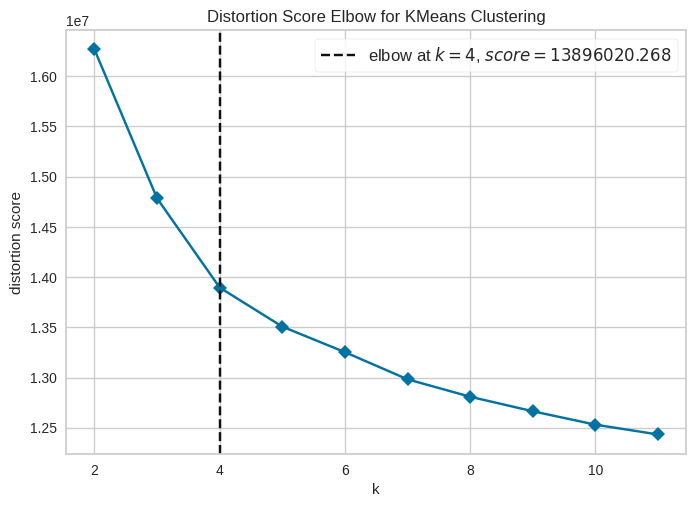

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [ ]:
# Initializing the cluster algorithm
KClusterer = KMeans(random_state = 2025)

# Initialize the elbow visualizer.
# This code was basically copied straight from Mar.20 lab.
visualizer = KElbowVisualizer(KClusterer, # Cluster model with any parameters you need
                              k = (2, 12), # Number of clusters to test (2 to 12 in this case)
                              locate_elbow = True, # Locate the elbow? Default is true.
                              timings = False # Plot the timings to train?
                             )

visualizer.fit(X) # Fit the visualizer
visualizer.show()

## Silhouette Scores

Two Approaches below:
1. Calculates Silhouette score and also provides Silhouette graph
2. Calculates Average Silhouette scores and presents them without a graph. There is a final graph that shows all scores at the end of run.

*Currently Commented out since it takes a long time to run*

Evaluating KMeans with 2 clusters
Average silhouette score for k = 2: 0.517


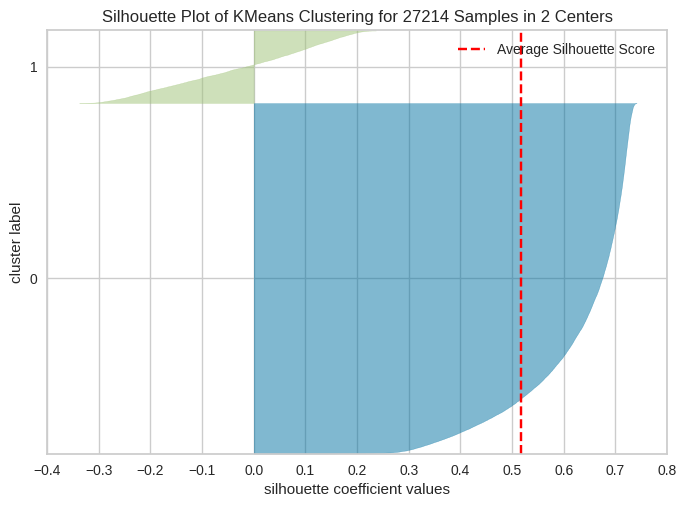

Evaluating KMeans with 3 clusters
Average silhouette score for k = 3: 0.364


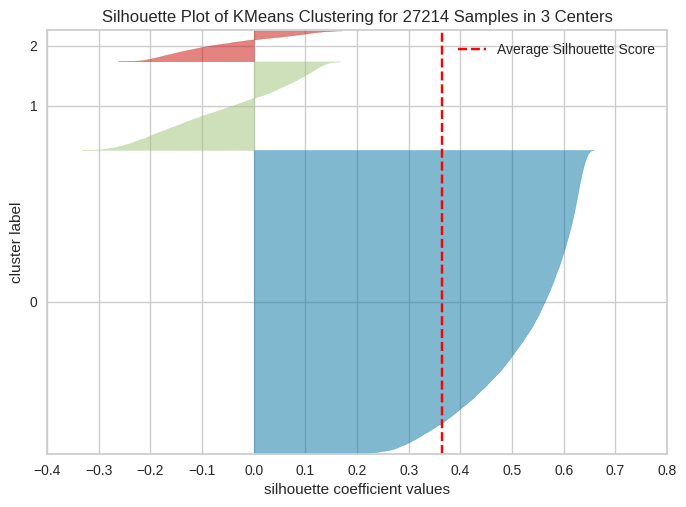

Evaluating KMeans with 4 clusters
Average silhouette score for k = 4: 0.266


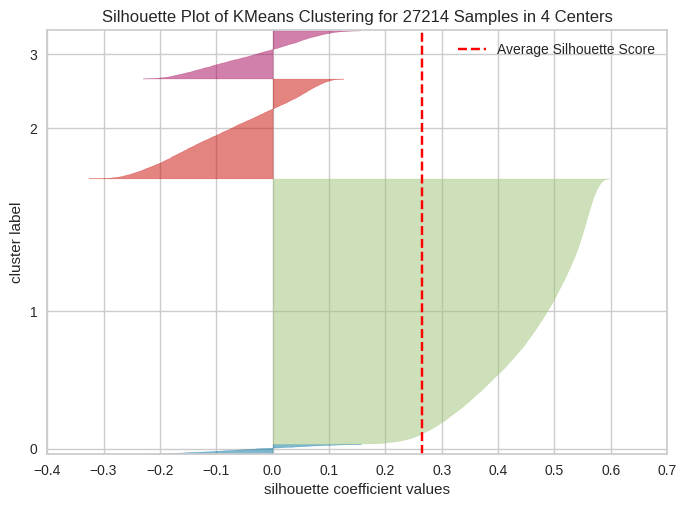

Evaluating KMeans with 5 clusters
Average silhouette score for k = 5: 0.171


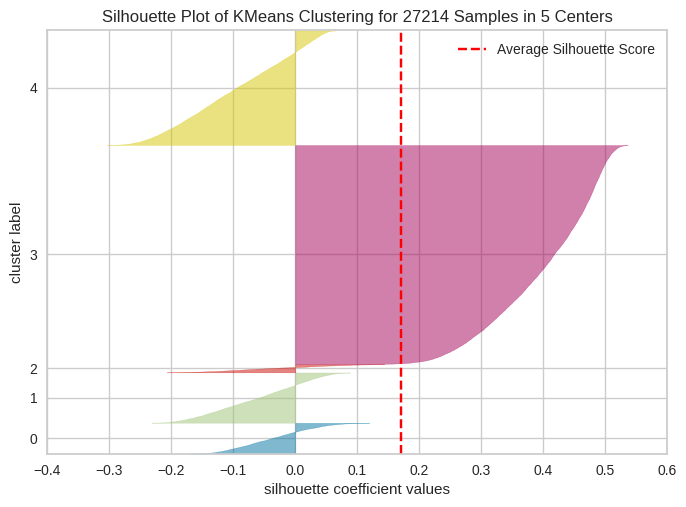

Evaluating KMeans with 6 clusters
Average silhouette score for k = 6: 0.160


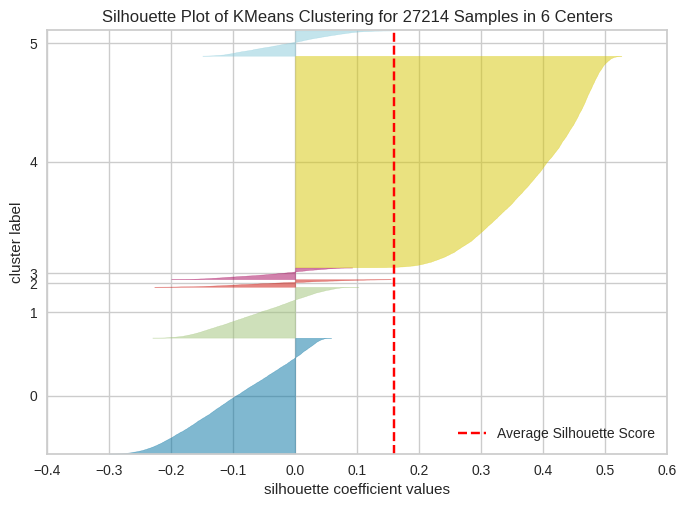

Evaluating KMeans with 7 clusters
Average silhouette score for k = 7: 0.128


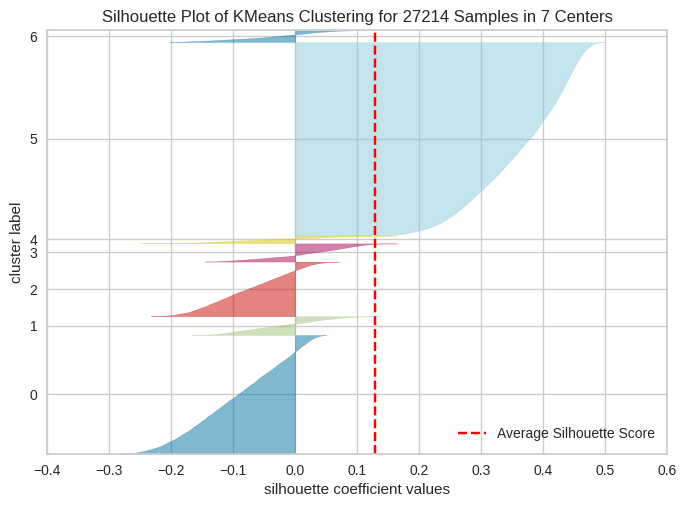

Evaluating KMeans with 8 clusters
Average silhouette score for k = 8: 0.135


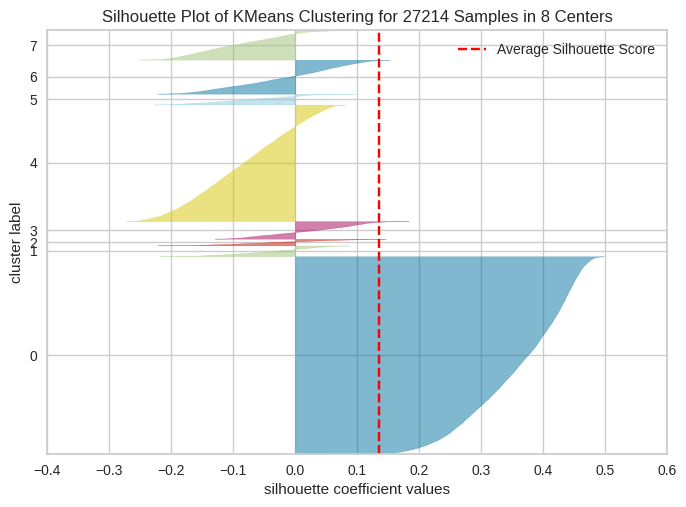

Evaluating KMeans with 9 clusters
Average silhouette score for k = 9: 0.079


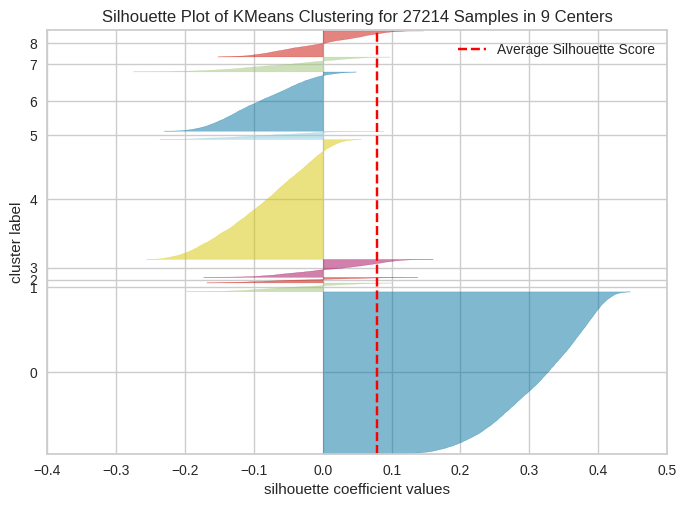

In [ ]:
# Silhouette with graphs
# Takes too long to run

# Loop through cluster counts from 2 to 9.
for n_clusters in range(2, 10):
    print("="*50)
    print(f"Evaluating KMeans with {n_clusters} clusters")

    # Create a pipeline: scale data and then apply KMeans.
    kmeans_pipe = Pipeline([
        # ('scale', StandardScaler()), # X is already scaled in a cell above
        ('kmeans', KMeans(n_clusters=n_clusters, n_init=10, random_state=2025))
    ])

    # Fit the pipeline to the training data.
    kmeans_pipe.fit(X)

    # Predict the cluster labels.
    cluster_labels = kmeans_pipe.predict(X)

    # Transform X_train using the scaler from the pipeline.
    # X_train_scaled = kmeans_pipe.named_steps['scale'].transform(X_train_scaled)

    # Calculate the average silhouette score.
    sil_score = silhouette_score(X, cluster_labels)
    print(f"Average silhouette score for k = {n_clusters}: {sil_score:.3f}")

    # Initialize and fit the Yellowbrick SilhouetteVisualizer.
    visualizer = SilhouetteVisualizer(kmeans_pipe.named_steps['kmeans'], colors='yellowbrick')
    visualizer.fit(X)
    visualizer.show()

In [ ]:
# Only Silhouette Averages are calculated here
# has a graph to show at the end (Not silhouette graph)
# Takes too long to run

silhouette_avgs = []

# Loop through cluster counts from 2 to 13.
for n_clusters in range(2, 9):
    # Initialize and fit the KMeans model
    kmeans = KMeans(n_clusters=n_clusters, n_init=10, random_state=2025)
    cluster_labels = kmeans.fit_predict(X)

    # Calculate the average silhouette score for the current number of clusters
    silhouette_avg = silhouette_score(X, cluster_labels)
    silhouette_avgs.append(silhouette_avg)
    print(f"For n_clusters = {n_clusters}, the average silhouette score is {silhouette_avg:.4f}")

For n_clusters = 2, the average silhouette score is 0.5172
For n_clusters = 3, the average silhouette score is 0.3638
For n_clusters = 4, the average silhouette score is 0.2659
For n_clusters = 5, the average silhouette score is 0.1709
For n_clusters = 6, the average silhouette score is 0.1597
For n_clusters = 7, the average silhouette score is 0.1283
For n_clusters = 8, the average silhouette score is 0.1347


## Fit Final KMeans and Assign Labels

In [ ]:
# Now that we've determined the optimal number of clusters, fit the final K-means

# Initialize and fit K-means
KClusterer = KMeans(n_clusters = 2, random_state = 2025)
KClusterer.fit(X)

# Get cluster labels for plotting later on
# This tells matplotlib or seaborn what colour each observation should be, based on cluster membership
labels = KClusterer.labels_

## Dimensionality Reduction with PCA

In [ ]:
# Principal component analysis

# Initialize PCA with 5 PCs.
pca = PCA(n_components = 5)

# Fit PCA to the standardized data and transform
X_pca = pca.fit_transform(X)

In [ ]:
# Look at the proportion of explain variance associated with each PC
# PC1 explains most of the variance
print(pca.explained_variance_ratio_)

[0.44438921 0.03756731 0.03502282 0.01953847 0.01537912]


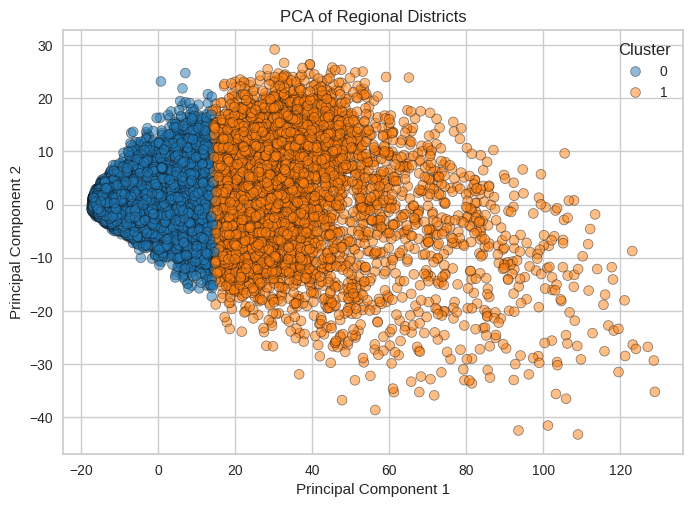

In [ ]:
# Create a new Seaborn scatter plot
sns.scatterplot(
    x = X_pca[:, 0], # PC1
    y = X_pca[:, 1], # PC2
    hue = labels, # Base the number of unique legend colours on the labels we saved previously
    palette = 'tab10',
    alpha = 0.5,
    edgecolor = 'k'
)

plt.title("PCA of Regional Districts")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title = 'Cluster', loc = 'best')

## Interpret PCA Loadings

In [ ]:
# Create a dataframe from PCA output using the first 3 components
# If changing the number of components, change the slicing of X_pca accordingly
df_pca = pd.DataFrame(X_pca[:, 0:3], columns = ["PC1", "PC2", "PC3"])

# Add cluster labels (which were stored previously)
df_pca["cluster"] = labels

# Group by cluster and compute average of each PC
# Apparently we don't need .agg() here because .mean() already does that
cluster_avg = df_pca.groupby("cluster").mean()

# Display the result
print(cluster_avg)

# Based on the PC loadings analysis below:
# Cluster 0: Slightly larger than average population, some cultural diversity, average incomes
# Cluster 1: Very large population but low-income and low-diversity
# Cluster 2: Large multicultural neighbourhoods with decent incomes
# Cluster 3: Slightly smaller than average population, average diversity and incomes

               PC1       PC2       PC3
cluster                               
0        -7.464308 -0.214369 -0.159080
1        36.135965  1.037798  0.770135


In [ ]:
# Get colnames from original dataframe without "CODE" column
feature_names = df_train_cleaned_clustering.drop("CODE").columns

# Create a dataframe of PCA loadings
loadings = pd.DataFrame(pca.components_,
                        columns = feature_names, # Set variable names as column labels
                        index = [f"PC{i+1}" for i in range(pca.n_components_)]) # Name rows as PC1, PC2, etc.

print(loadings)


     HSBASHHD  HSAGDISPIN  HSAGDISCIN   HSTT001   HSTE001   HSTX001   HSTC001  \
PC1  0.044974    0.047205    0.046668  0.046331  0.046680  0.041103  0.047568   
PC2 -0.005363   -0.026221   -0.032599 -0.029351 -0.029074 -0.034443 -0.025236   
PC3 -0.060328    0.011886    0.014191  0.035815  0.020701  0.045696  0.011510   
PC4  0.013723    0.015333    0.017505  0.015170  0.019379  0.035105  0.012584   
PC5 -0.001449    0.024073    0.023202  0.026828  0.031931  0.060122  0.021786   

     HSSH001S  HSFD001S  HSHO001S  ...  ECYGEN1GEN  ECYGEN2GEN  ECYGEN3GEN  \
PC1  0.047100  0.047580  0.047254  ...    0.033169    0.040591    0.035777   
PC2 -0.008652 -0.026612 -0.026738  ...    0.090373    0.048450   -0.064361   
PC3  0.017858  0.002156  0.008205  ...    0.017124    0.033269   -0.038413   
PC4  0.020632  0.009844  0.014179  ...    0.062174    0.025153   -0.053368   
PC5  0.022714  0.019840  0.017586  ...    0.002234   -0.022222    0.004646   

     ECYTCAHPOP  ECYTCACIT  ECYTCA_U18  ECYT

In [ ]:
# Making a dataframe of variable names and their descriptions
# This will be used for matching variable descriptions to their codes
# when inspecting PC loadings.
demo_metadata = pd.read_csv("/content/drive/My Drive/DS3000/coursework_data/DemoStats 2024 - Metadata.csv")
# demo_metadata = pd.read_csv("D:\\ds_3000_project\\DemoStats 2024 - Metadata.csv") # For local work
demo_metadata = demo_metadata[["Variable", "Description"]]

household_metadata = pd.read_csv("/content/drive/My Drive/DS3000/coursework_data/HouseholdSpend 2024 - Metadata.csv")
# household_metadata = pd.read_csv("D:\\ds_3000_project\\coursework_data/HouseholdSpend 2024 - Metadata.csv")
household_metadata = household_metadata[["Variable", "Description"]]
household_metadata = household_metadata.drop([0, 1]) # Drop the first two rows because they already exist in the demographics metadata
household_metadata = household_metadata.reset_index(drop = True) # Reset the index

metadata_df = pd.concat([demo_metadata, household_metadata], ignore_index = True)

In [ ]:
# Inspecting the loadings for PC1
(loadings.loc["PC1"]
    .sort_values(ascending = False)
    .reset_index().rename(columns = {"index" : "Variable"})
    .merge(metadata_df, on = "Variable", how = "left")
    .head(20))

# Based on the loadings, we'd call PC1 "Neighbourhoods with large populations"

,Variable,PC1,Description
0,ECYHOMSING,0.048141,Single Responses
1,ECYMOTSING,0.048122,Total Single Response
2,ECYMOBHPOP,0.048095,Household Population For 5 Year Mobility Status
3,ECYPIMHPOP,0.048085,Household Population For Period Of Immigration
4,ECYVISHPOP,0.048085,Household Population For Visible Minority
5,ECYAIDHPOP,0.048085,Household Population For Indigenous Identity
6,ECYKNOHPOP,0.048085,Household Population For Knowledge Of Official...
7,ECYTIMHPOP,0.048085,Total Household Population
8,ECYHOMHPOP,0.048085,Household Population For Home Language
9,ECYMOTHPOP,0.048085,Household Population For Mother Tongue


In [ ]:
# Inspecting the loadings for PC2
(loadings.loc["PC2"]
    .sort_values(ascending = False)
    .reset_index().rename(columns = {"index" : "Variable"})
    .merge(metadata_df, on = "Variable", how = "left")
    .head(20))

# Based on the loadings, we'd call PC2 "High Presence of Immigrant Households"

,Variable,PC2,Description
0,ECYHOMNOFF,0.098635,Non-Official Languages
1,ECYVISVM,0.095349,Visible Minority Total
2,ECYMOTNOFF,0.093536,Total Non-Official
3,ECYGEN1GEN,0.090373,First Generation
4,ECYHOMENON,0.090326,English & Non-Official
5,ECYTIMA,0.090133,Asia
6,ECYAIM2544,0.087867,25 To 44 Years
7,ECYMOTENON,0.087836,English & Non-Official
8,ECYTIMIMGT,0.087419,Total Immigrant
9,ECYAIMIM,0.087419,Immigrants


In [ ]:
# Inspecting the loadings for PC3
(loadings.loc["PC3"]
    .sort_values(ascending = False)
    .reset_index().rename(columns = {"index" : "Variable"})
    .merge(metadata_df, on = "Variable", how = "left")
    .head(20))

# Based on the loadings, we'd call PC2 "Wealthy Neighbourhoods"

,Variable,PC3,Description
0,HSWH040S,0.117360,Net purchase price of owned residences
1,HSTE001ZBS,0.111321,Total non-current consumption
2,ECYHNIAVG,0.105966,Average Household Income (Current Year $)
3,ECYHRIAVG,0.105966,Average Household Income (Constant Year 2020 $)
4,ECYHNIMED,0.101183,Median Household Income (Current Year $)
5,ECYHRIMED,0.101068,Median Household Income (Constant Year 2020 $)
6,HSSH033A,0.097322,Natural gas charges for owned principal residence
7,ECYHSZAVG,0.091625,Average Number Of Persons In Private Households
8,HSSH033,0.091091,Natural gas
9,HSRM013,0.084909,Heating and/or air conditioning equipment


## Alternative Visualization Using UMAP

In [ ]:
import umap

# Store best results
best_silhouette = -1
best_embedding = None
best_params = {}

# Try combinations of neighbors and min_dist
neighbors_options = [10, 30, 50]
min_dist_options = [0.0, 0.3, 0.8]

for n in neighbors_options:
    for d in min_dist_options:
        print(f"Training UMAP with n_neighbors={n}, min_dist={d}...")

        # Create UMAP object
        reducer = umap.UMAP(n_neighbors=n,
                            n_components=2,
                            metric='cosine',
                            n_epochs=1000,
                            min_dist=d,
                            spread=1.0,
                            low_memory=False,
                            n_jobs=-1,
                            verbose=True,
                            random_state=2025)

        # Train UMAP and get embedding
        embedding = reducer.fit_transform(X)

        # Evaluate using silhouette score
        score = silhouette_score(embedding, labels)
        print(f"Silhouette Score: {score:.4f}")

        # Save if it's the best so far
        if score > best_silhouette:
            best_silhouette = score
            best_embedding = embedding
            best_params = {'n_neighbors': n, 'min_dist': d}

# Output best result
print("\nBest UMAP Parameters:")
print(best_params)
print(f"Best Silhouette Score: {best_silhouette:.4f}")

Training UMAP with n_neighbors=10, min_dist=0.0...
UMAP(angular_rp_forest=True, low_memory=False, metric='cosine', min_dist=0.0, n_epochs=1000, n_jobs=1, n_neighbors=10, random_state=2025, verbose=True)
Sun Apr 20 10:16:44 2025 Construct fuzzy simplicial set
Sun Apr 20 10:16:44 2025 Finding Nearest Neighbors
Sun Apr 20 10:16:44 2025 Building RP forest with 13 trees


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Sun Apr 20 10:16:51 2025 NN descent for 15 iterations
	 1  /  15
	 2  /  15
	 3  /  15
	 4  /  15
	 5  /  15
	 6  /  15
	 7  /  15
	 8  /  15
	 9  /  15
	Stopping threshold met -- exiting after 9 iterations
Sun Apr 20 10:17:08 2025 Finished Nearest Neighbor Search
Sun Apr 20 10:17:10 2025 Construct embedding


Epochs completed:   0%|            0/1000 [00:00]

	completed  0  /  1000 epochs
	completed  100  /  1000 epochs
	completed  200  /  1000 epochs
	completed  300  /  1000 epochs
	completed  400  /  1000 epochs
	completed  500  /  1000 epochs
	completed  600  /  1000 epochs
	completed  700  /  1000 epochs
	completed  800  /  1000 epochs
	completed  900  /  1000 epochs
Sun Apr 20 10:18:06 2025 Finished embedding
Silhouette Score: 0.2926
Training UMAP with n_neighbors=10, min_dist=0.3...
UMAP(angular_rp_forest=True, low_memory=False, metric='cosine', min_dist=0.3, n_epochs=1000, n_jobs=1, n_neighbors=10, random_state=2025, verbose=True)
Sun Apr 20 10:18:14 2025 Construct fuzzy simplicial set
Sun Apr 20 10:18:14 2025 Finding Nearest Neighbors
Sun Apr 20 10:18:14 2025 Building RP forest with 13 trees


...

	completed  0  /  1000 epochs
	completed  100  /  1000 epochs
	completed  200  /  1000 epochs
	completed  300  /  1000 epochs
	completed  400  /  1000 epochs
	completed  500  /  1000 epochs
	completed  600  /  1000 epochs
	completed  700  /  1000 epochs
	completed  800  /  1000 epochs
	completed  900  /  1000 epochs
Sun Apr 20 10:31:06 2025 Finished embedding
Silhouette Score: 0.3340
Training UMAP with n_neighbors=50, min_dist=0.8...
UMAP(angular_rp_forest=True, low_memory=False, metric='cosine', min_dist=0.8, n_epochs=1000, n_jobs=1, n_neighbors=50, random_state=2025, verbose=True)
Sun Apr 20 10:31:15 2025 Construct fuzzy simplicial set
Sun Apr 20 10:31:15 2025 Finding Nearest Neighbors
Sun Apr 20 10:31:15 2025 Building RP forest with 13 trees


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Sun Apr 20 10:31:16 2025 NN descent for 15 iterations
	 1  /  15
	 2  /  15
	 3  /  15
	 4  /  15
	 5  /  15
	 6  /  15
	Stopping threshold met -- exiting after 6 iterations
Sun Apr 20 10:31:53 2025 Finished Nearest Neighbor Search
Sun Apr 20 10:31:54 2025 Construct embedding


Epochs completed:   0%|            0/1000 [00:00]

	completed  0  /  1000 epochs
	completed  100  /  1000 epochs
	completed  200  /  1000 epochs
	completed  300  /  1000 epochs
	completed  400  /  1000 epochs
	completed  500  /  1000 epochs
	completed  600  /  1000 epochs
	completed  700  /  1000 epochs
	completed  800  /  1000 epochs
	completed  900  /  1000 epochs
Sun Apr 20 10:33:32 2025 Finished embedding
Silhouette Score: 0.3368

Best UMAP Parameters:
{'n_neighbors': 50, 'min_dist': 0.0}
Best Silhouette Score: 0.3775


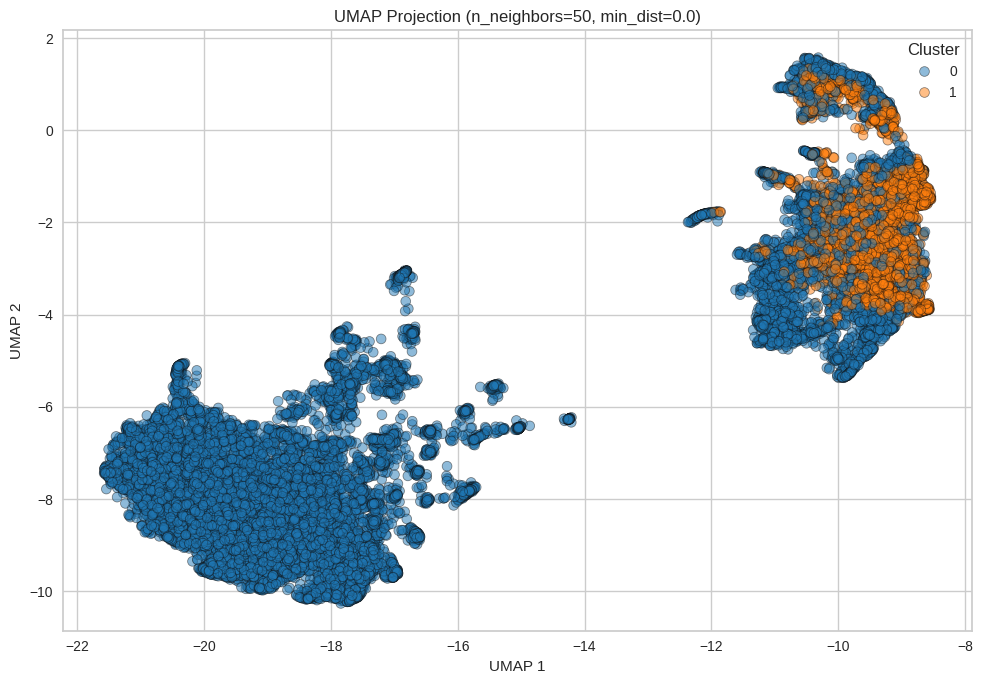

In [ ]:
# Plot final UMAP embedding
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x = best_embedding[:, 0],
    y = best_embedding[:, 1],
    hue = labels,
    palette = 'tab10',
    alpha = 0.5,
    edgecolor = 'k'
)

plt.title(f"UMAP Projection (n_neighbors={best_params['n_neighbors']}, min_dist={best_params['min_dist']})")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.legend(title='Cluster')
plt.grid(True)
plt.tight_layout()
plt.show()

# Regression Modeling – Part 2 of Assignment
- Predict insurance & pension contributions as a proportion of income.

## Train/Validation Split (commented out because I made the validation set earlier now)

## Create Target Variable

In [ ]:
target_col_name = "insurance_pension_ratio"
col_contrib = "HSEP001S"
col_income = "HSHNIAGG"

# Function to calculate the ratio
def calculate_target(df, contrib_col, income_col, target_name):
    return df.with_columns(
        (pl.col(contrib_col) / pl.col(income_col)).alias(target_name)
    )

# Calculate targets for train, val, and test
df_train_final_xgb = calculate_target(train_df.drop("CODE"), col_contrib, col_income, target_col_name)
df_val_xgb = calculate_target(val_df.drop("CODE"), col_contrib, col_income, target_col_name)
df_test_xgb = calculate_target(test_df.drop("CODE"), col_contrib, col_income, target_col_name)

In [ ]:
# Checking target variable descriptive stats
print("Target Variable Descriptive Statistics (Training Set):")
print(df_train_final_xgb.select(target_col_name).describe())

print("Target Variable Descriptive Statistics (Validation Set):")
print(df_val_xgb.select(target_col_name).describe())

print("\nTarget Variable Descriptive Statistics (Test Set):")
print(df_test_xgb.select(target_col_name).describe())

Target Variable Descriptive Statistics (Training Set):
shape: (9, 2)
┌────────────┬─────────────────────────┐
│ statistic  ┆ insurance_pension_ratio │
│ ---        ┆ ---                     │
│ str        ┆ f64                     │
╞════════════╪═════════════════════════╡
│ count      ┆ 54429.0                 │
│ null_count ┆ 0.0                     │
│ mean       ┆ 0.053743                │
│ std        ┆ 0.015747                │
│ min        ┆ 0.002876                │
│ 25%        ┆ 0.044612                │
│ 50%        ┆ 0.054036                │
│ 75%        ┆ 0.063487                │
│ max        ┆ 0.132546                │
└────────────┴─────────────────────────┘
Target Variable Descriptive Statistics (Validation Set):
shape: (9, 2)
┌────────────┬─────────────────────────┐
│ statistic  ┆ insurance_pension_ratio │
│ ---        ┆ ---                     │
│ str        ┆ f64                     │
╞════════════╪═════════════════════════╡
│ count      ┆ 11663.0                 │

## Extract Final Features and Targets for Modeling

In [ ]:
# Drop unnecessary columns
cols_to_drop_for_xgb = [target_col_name, col_contrib, col_income]

# Extract features and target for training and validation
X_train_pl = df_train_final_xgb.drop(cols_to_drop_for_xgb)
y_train_pl = df_train_final_xgb.select(target_col_name)

X_val_pl = df_val_xgb.drop(cols_to_drop_for_xgb)
y_val_pl = df_val_xgb.select(target_col_name)

X_test_pl = df_test_xgb.drop(cols_to_drop_for_xgb)
y_test_pl = df_test_xgb.select(target_col_name)

# Convert to pandas/numpy
X_train = X_train_pl.to_pandas()
y_train = y_train_pl.to_numpy().ravel()

X_val = X_val_pl.to_pandas()
y_val = y_val_pl.to_numpy().ravel()

X_test = X_test_pl.to_pandas()
y_test = y_test_pl.to_numpy().ravel()

In [ ]:
print(f"\nFeature shapes: X_train={X_train.shape}, X_val={X_val.shape}, X_test={X_test.shape}")
print(f"Target shapes: y_train={y_train.shape}, y_val={y_val.shape}, y_test={y_test.shape}")


Feature shapes: X_train=(54429, 967), X_val=(11663, 967), X_test=(11665, 967)
Target shapes: y_train=(54429,), y_val=(11663,), y_test=(11665,)


Beginning of Joel's PCA Elastic Net code

In [ ]:
# Select only numeric columns from X_train and X_test
# X_train = X_train.select(pl.col(pl.NUMERIC_DTYPES))
# X_val = X_val.select(pl.col(pl.NUMERIC_DTYPES))
# X_test = X_test.select(pl.col(pl.NUMERIC_DTYPES))

# print("Scaling Data")

# Initialize the StandardScaler
scaler = StandardScaler()
# Fit the scaler to the training data and transform both training and test data
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Scaling Completed")

Scaling Completed


In [ ]:
# X_train_scaled is scaled training data.
pca_full = PCA(n_components=None, random_state=2025)
pca_full.fit(X_train_scaled)

# Get cumulative explained variance for all components
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

for i in range(1, 9):
    variance = cumulative_variance[i * 100 - 1]
    info_loss = 1 - variance
    print(f"Variance retained with {i * 100} components: {variance:.6%}")
    print(f"Information lost with {i * 100} components: {info_loss:.6%}")

Variance retained with 100 components: 89.469651%
Information lost with 100 components: 10.530349%
Variance retained with 200 components: 96.064985%
Information lost with 200 components: 3.935015%
Variance retained with 300 components: 98.710222%
Information lost with 300 components: 1.289778%
Variance retained with 400 components: 99.641378%
Information lost with 400 components: 0.358622%
Variance retained with 500 components: 99.933600%
Information lost with 500 components: 0.066400%
Variance retained with 600 components: 99.997797%
Information lost with 600 components: 0.002203%
Variance retained with 700 components: 100.000000%
Information lost with 700 components: -0.000000%
Variance retained with 800 components: 100.000000%
Information lost with 800 components: -0.000000%


In [ ]:
# First ensure that data is in NumPy format for scikitlearn
def ensure_numpy(data):
    if isinstance(data, pd.DataFrame):
        return data.values
    elif hasattr(data, "to_numpy"):
        return data.to_numpy()
    return data

X_train_scaled = ensure_numpy(X_train_scaled)
y_train = ensure_numpy(y_train)
X_val_scaled = ensure_numpy(X_val_scaled)
y_val = ensure_numpy(y_val)

print("Data shapes:")
print("  X_train_scaled:", X_train_scaled.shape)
print("  y_train:", y_train.shape)
print("  X_val_scaled:", X_val_scaled.shape)
print("  y_val:", y_val.shape)

Data shapes:
  X_train_scaled: (54429, 967)
  y_train: (54429,)
  X_val_scaled: (11663, 967)
  y_val: (11663,)


In [ ]:
# (Optional) Subsample Training Data for Grid Search
subsample_size = 20000
if X_train_scaled.shape[0] > subsample_size:
    np.random.seed(2025)
    sample_indices = np.random.choice(X_train_scaled.shape[0], subsample_size, replace=False)
    X_train_sub = X_train_scaled[sample_indices]
    y_train_sub = y_train[sample_indices]
else:
    X_train_sub = X_train_scaled
    y_train_sub = y_train

print("Subsample shapes:")
print("  X_train_sub:", X_train_sub.shape)
print("  y_train_sub:", y_train_sub.shape)

Subsample shapes:
  X_train_sub: (20000, 967)
  y_train_sub: (20000,)


In [ ]:
# Build a Pipeline with PCA and ElasticNet

pipeline = Pipeline([
    ('pca', PCA()), # ('pca', PCA(n_components=600, random_state=2025))
    ('elasticnet', ElasticNet(random_state=2025, warm_start=True))
])

# Set up the hyperparameter grid for both PCA and ElasticNet.
param_grid = {
    'elasticnet__alpha': [0.005, 0.01, 0.05, 0.1],
    'elasticnet__l1_ratio': [0.0005, 0.001, 0.005, 0.01,],
    'elasticnet__max_iter': [5000, 10000, 20000],
}

cv_object = KFold(n_splits=3, shuffle=True, random_state=2025)

# Using both r2 and negative MSE for scoring, and refitting based on r2.
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=cv_object,
    scoring=['r2', 'neg_mean_squared_error'],
    n_jobs=-1,
    refit='r2',
    verbose=2
)

print("\nStarting GridSearchCV on subsampled training data with PCA...")
grid_search.fit(X_train_sub, y_train_sub)
print("Best parameters found:")
print(grid_search.best_params_)


Starting GridSearchCV on subsampled training data with PCA...
Fitting 3 folds for each of 48 candidates, totalling 144 fits
Best parameters found:
{'elasticnet__alpha': 0.05, 'elasticnet__l1_ratio': 0.005, 'elasticnet__max_iter': 5000}


Building Elastic Net Model

In [ ]:
# New code Joel updated
# Making pca df for train and test
pca = PCA(n_components=600, random_state=2025)
# Fit PCA on training data
X_train_pca = pca.fit_transform(X_train_scaled)
# Apply the same transformation to the test data
X_test_pca = pca.transform(X_test_scaled)

print("Shape after PCA - Training:", X_train_pca.shape)
print("Shape after PCA - Test:", X_test_pca.shape)

# Refit the Final Model on the Full Training Data
# Use the best parameters from the grid search.
elastic_model = ElasticNet(
    alpha=0.05,
    l1_ratio=0.001,
    max_iter=5000,
    random_state=2025,
    warm_start=True
)

print("\nRefitting final model on full training data...")
elastic_model.fit(X_train_pca, y_train)

# Getting evaluation on training set
train_r2 = elastic_model.score(X_train_pca, y_train)
print(f"Training R² on PCA‐space: {train_r2:.3f}")


Shape after PCA - Training: (54429, 600)
Shape after PCA - Test: (11665, 600)

Refitting final model on full training data...
Training R² on PCA‐space: 0.451


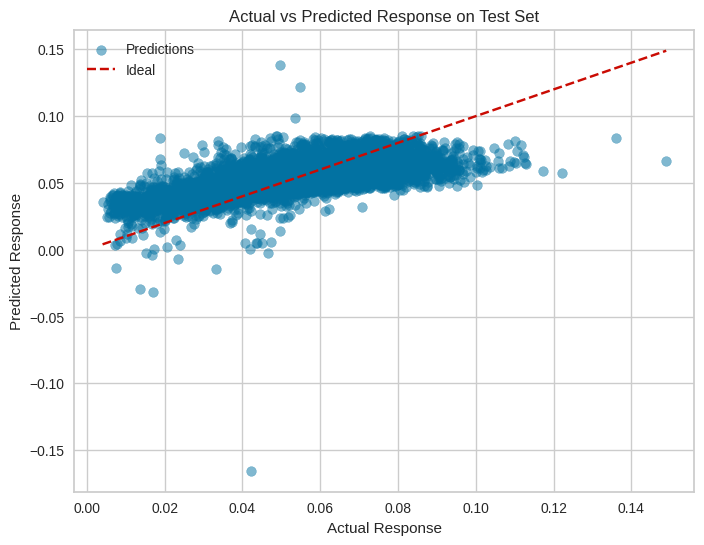

In [ ]:
# Joel updated
# Predict on Test Set and Create Scatterplot
predictions = elastic_model.predict(X_test_pca)

plt.figure(figsize=(8,6))
plt.scatter(y_test, predictions, alpha=0.5, label="Predictions")
# Convert y_test to a Series using to_series() before using min/max.
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', label="Ideal")
plt.xlabel("Actual Response")
plt.ylabel("Predicted Response")
plt.title("Actual vs Predicted Response on Test Set")
plt.legend()
plt.show()

In [ ]:
# MSE, RMSE, R², and Bootstrapped Confidence Intervals

mse = mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)
print("Test Set Metrics:")
print(f"Mean Squared Error (MSE): {mse:.6f}")
print(f"R² Score: {r2:.3f}")

def bootstrap_metric(metric_func, y_true, y_pred, n_iterations=1000, random_state=2025):
    np.random.seed(random_state)
    metric_vals = []
    n = len(y_true)
    for _ in range(n_iterations):
        indices = np.random.randint(0, n, n)
        metric_val = metric_func(y_true[indices], y_pred[indices])
        metric_vals.append(metric_val)
    lower = np.percentile(metric_vals, 2.5)
    upper = np.percentile(metric_vals, 97.5)
    return lower, upper

mse_ci = bootstrap_metric(mean_squared_error, np.array(y_test), np.array(predictions))
r2_ci = bootstrap_metric(r2_score, np.array(y_test), np.array(predictions))

print("\nBootstrapped 95% Confidence Intervals:")
print(f"MSE: {mse_ci[0]:.6f} to {mse_ci[1]:.6f}")
print(f"R²: {r2_ci[0]:.3f} to {r2_ci[1]:.3f}")

Test Set Metrics:
Mean Squared Error (MSE): 0.000144
R² Score: 0.433

Bootstrapped 95% Confidence Intervals:
MSE: 0.000137 to 0.000154
R²: 0.398 to 0.458


<ipython-input-85-3019fa725bfb>:12: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


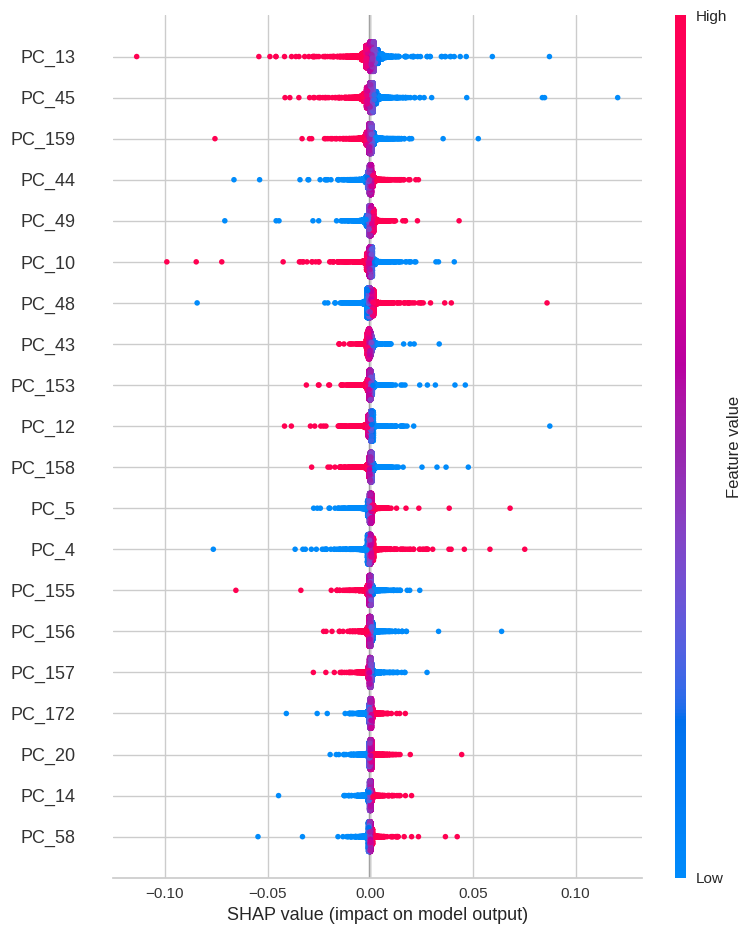

<ipython-input-85-3019fa725bfb>:23: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


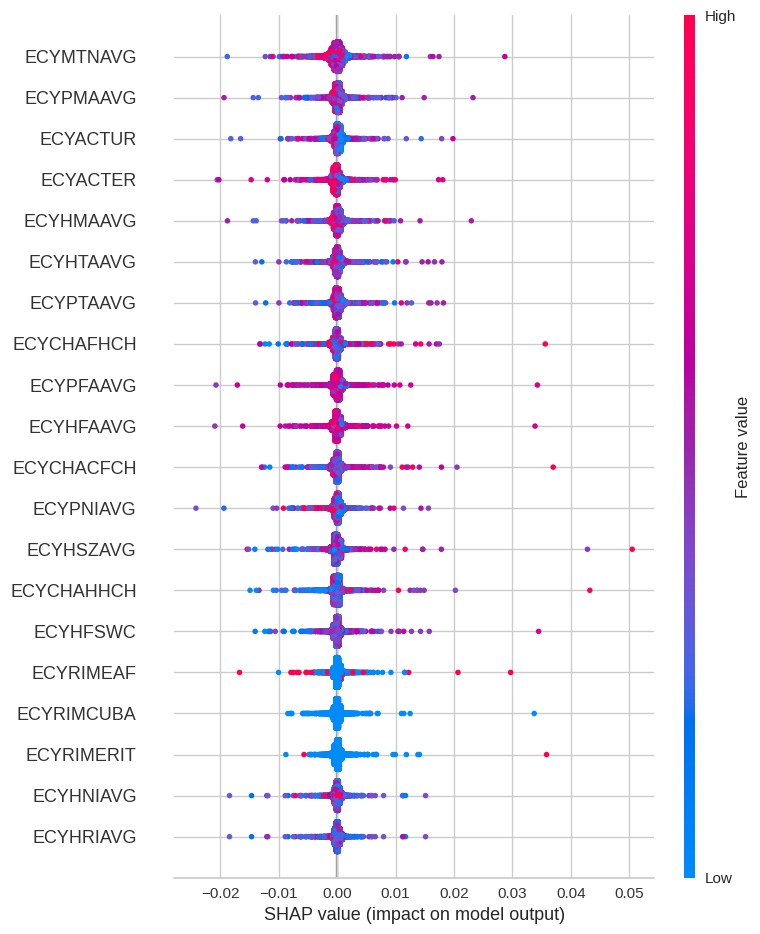

In [ ]:
# Original feature names from Polars X_train DataFrame
original_feature_names = X_train.columns

# Build the explainer on the already‑fitted ElasticNet in PC‑space
masker    = shap.maskers.Independent(X_train_pca)
explainer = shap.LinearExplainer(elastic_model, masker)

# Compute SHAP values for test set (in PC‐space)
shap_pca = explainer.shap_values(X_test_pca)

# Bar summary of which PRINCIPAL COMPONENTS matter most
shap.summary_plot(
    shap_pca,
    X_test_pca,
    feature_names=[f"PC_{i+1}" for i in range(X_test_pca.shape[1])],
    plot_type="dot"
)

# Project those PC‑SHAP values back to ORIGINAL FEATURES:
shap_orig = shap_pca.dot(pca.components_)

# Bar summary of which ORIGINAL FEATURES matter most
shap.summary_plot(
    shap_orig,
    X_test_scaled,
    feature_names=original_feature_names,
    plot_type="dot"
)

Beginning of Meghan's Elastic Net code

In [ ]:
# Already dropped above
# X_train = X_train.drop("CODE")
# X_test = X_test.drop("CODE")
# X_val =X_val.drop("CODE")

In [ ]:
tracking_seed = 2025

In [ ]:
l1_candidates = [0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1]
alpha_candidates = np.logspace(-3, 1, 100)

EN_CV = ElasticNetCV(alphas=alpha_candidates,
                     l1_ratio=l1_candidates,
                     cv=5,
                     n_jobs=2,
                     random_state=tracking_seed,
                     max_iter=20000,
                     tol=1e-3,
                     verbose=2)

EN_CV_pipe = Pipeline(
    steps=[('scaler', StandardScaler()),
           ('EN_CV', EN_CV)]
)

EN_CV_pipe.fit(X_train, y_train)

[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.


Path: 000 out of 100
Path: 001 out of 100
Path: 002 out of 100
Path: 003 out of 100
Path: 004 out of 100
Path: 005 out of 100
Path: 006 out of 100
Path: 007 out of 100
Path: 008 out of 100
Path: 009 out of 100
Path: 010 out of 100
Path: 011 out of 100
Path: 012 out of 100
Path: 013 out of 100
Path: 014 out of 100
Path: 015 out of 100
Path: 016 out of 100
Path: 017 out of 100
Path: 018 out of 100
Path: 019 out of 100
Path: 020 out of 100
Path: 021 out of 100
Path: 022 out of 100
Path: 023 out of 100
Path: 024 out of 100
Path: 025 out of 100
Path: 026 out of 100
Path: 027 out of 100
Path: 028 out of 100
Path: 029 out of 100
Path: 030 out of 100
Path: 031 out of 100
Path: 032 out of 100
Path: 033 out of 100
Path: 000 out of 100
Path: 001 out of 100
Path: 002 out of 100
Path: 003 out of 100
Path: 004 out of 100
Path: 005 out of 100
Path: 006 out of 100
Path: 007 out of 100
Path: 034 out of 100
Path: 035 out of 100
Path: 036 out of 100
Path: 037 out of 100
Path: 038 out of 100
Path: 039 out

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.038018646329152084, tolerance: 0.010745350171058668
  model = cd_fast.enet_coordinate_descent_gram(


Path: 085 out of 100
Path: 089 out of 100
Path: 090 out of 100
Path: 086 out of 100
Path: 091 out of 100
Path: 092 out of 100


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.02450216211104639, tolerance: 0.010745350171058668
  model = cd_fast.enet_coordinate_descent_gram(


...

Path: 098 out of 100
Path: 096 out of 100
Path: 097 out of 100
Path: 098 out of 100
Path: 099 out of 100
Path: 000 out of 100
Path: 001 out of 100
Path: 002 out of 100
Path: 003 out of 100
Path: 004 out of 100
Path: 005 out of 100
Path: 006 out of 100
Path: 007 out of 100
Path: 008 out of 100
Path: 009 out of 100
Path: 010 out of 100
Path: 011 out of 100
Path: 012 out of 100
Path: 013 out of 100
Path: 014 out of 100
Path: 015 out of 100
Path: 016 out of 100
Path: 017 out of 100
Path: 018 out of 100
Path: 019 out of 100
Path: 020 out of 100
Path: 021 out of 100
Path: 022 out of 100
Path: 023 out of 100
Path: 024 out of 100
Path: 025 out of 100
Path: 026 out of 100
Path: 027 out of 100
Path: 028 out of 100
Path: 029 out of 100
Path: 030 out of 100
Path: 031 out of 100
Path: 032 out of 100
Path: 033 out of 100
Path: 034 out of 100
Path: 035 out of 100
Path: 036 out of 100
Path: 037 out of 100
Path: 038 out of 100
Path: 039 out of 100
Path: 040 out of 100
Path: 041 out of 100
Path: 042 out

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.012816753175349582, tolerance: 0.010842272545440557
  model = cd_fast.enet_coordinate_descent_gram(


Path: 099 out of 100
Path: 089 out of 100
Path: 090 out of 100
Path: 091 out of 100
Path: 092 out of 100
Path: 000 out of 100
Path: 001 out of 100
Path: 002 out of 100
Path: 003 out of 100
Path: 004 out of 100
Path: 005 out of 100
Path: 006 out of 100
Path: 007 out of 100
Path: 008 out of 100
Path: 009 out of 100
Path: 010 out of 100
Path: 011 out of 100
Path: 012 out of 100
Path: 013 out of 100
Path: 014 out of 100
Path: 015 out of 100
Path: 016 out of 100
Path: 017 out of 100
Path: 018 out of 100
Path: 019 out of 100
Path: 020 out of 100
Path: 021 out of 100
Path: 022 out of 100
Path: 023 out of 100
Path: 024 out of 100
Path: 025 out of 100
Path: 026 out of 100
Path: 027 out of 100
Path: 028 out of 100
Path: 029 out of 100
Path: 030 out of 100
Path: 031 out of 100
Path: 032 out of 100
Path: 033 out of 100
Path: 034 out of 100
Path: 035 out of 100
Path: 036 out of 100
Path: 037 out of 100
Path: 038 out of 100
Path: 039 out of 100
Path: 040 out of 100
Path: 041 out of 100
Path: 042 out

[Parallel(n_jobs=2)]: Done  35 out of  35 | elapsed:  9.1min finished


Pipeline(steps=[('scaler', StandardScaler()),
                ('EN_CV',
                 ElasticNetCV(alphas=array([1.00000000e-03, 1.09749877e-03, 1.20450354e-03, 1.32194115e-03,
       1.45082878e-03, 1.59228279e-03, 1.74752840e-03, 1.91791026e-03,
       2.10490414e-03, 2.31012970e-03, 2.53536449e-03, 2.78255940e-03,
       3.05385551e-03, 3.35160265e-03, 3.67837977e-03, 4.03701726e-03,
       4.43062146e-03, 4.86260158e-03,...
       2.47707636e+00, 2.71858824e+00, 2.98364724e+00, 3.27454916e+00,
       3.59381366e+00, 3.94420606e+00, 4.32876128e+00, 4.75081016e+00,
       5.21400829e+00, 5.72236766e+00, 6.28029144e+00, 6.89261210e+00,
       7.56463328e+00, 8.30217568e+00, 9.11162756e+00, 1.00000000e+01]),
                              cv=5,
                              l1_ratio=[0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1],
                              max_iter=20000, n_jobs=2, random_state=2025,
                              tol=0.001, verbose=2))])

In [ ]:
# Access the fitted ElasticNetCV step
fitted_en_cv = EN_CV_pipe.named_steps['EN_CV']
best_alpha = fitted_en_cv.alpha_
best_l1_ratio = fitted_en_cv.l1_ratio_
coefs = fitted_en_cv.coef_
intercept = fitted_en_cv.intercept_

In [ ]:
# Get the best alpha (as you already have)
best_alpha = 0.0027825594022071257

# Get the best l1_ratio
best_l1_ratio = 0.1

In [ ]:
elasNet_opt = ElasticNet(alpha = best_alpha,
                         l1_ratio = best_l1_ratio,
                         max_iter = 20000,
                         random_state = tracking_seed)

elasNet_pipe_opt = Pipeline([('scaler', StandardScaler()),
                             ('elasNet_opt', elasNet_opt)])

elasNet_pipe_opt.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('elasNet_opt',
                 ElasticNet(alpha=0.0027825594022071257, l1_ratio=0.1,
                            max_iter=20000, random_state=2025))])

In [ ]:
# # Define the ElasticNet Regression
# elastic_Net = ElasticNet(random_state=2025)

# # Define cross-valdiation object using 3-fold CV
# cv_object = KFold(n_splits = 3,
#                   shuffle = True,
#                   random_state=2025)

# # Define the parameter grid for alpha (learning rate) and l1 ratio
# param_grid_elas = dict({'alpha': [0.008, 0.01, 0.015, 0.1],
#                         'l1_ratio': [0.003, 0.008, 0.01, 0.05],
#                         'max_iter': [8000, 10000, 12000]})

# # Define the Grid Search object that will help us determine the best hyperparameters
# # for our model
# grid_elas = GridSearchCV(elastic_Net,
#                           param_grid_elas,
#                           cv = cv_object,
#                           scoring = ['r2', 'neg_mean_squared_error'],
#                           refit = 'r2',
#                           n_jobs = -1,
#                           verbose = 2)

# ElasNet_pipe = Pipeline(
#     steps=[('scaler', StandardScaler()),
#            ('elastic_net', grid_elas)]
# )

# ElasNet_pipe.fit(X_train, Y_train)
# ElasNet_pipe.named_steps['elastic_net'].best_params_

Create an Elastic Net model with the optimal parameters as determined by the GridSearchCV and train it.

In [ ]:
# opt_alpha = 0.015
# opt_l1_ratio = 0.01
# opt_max_iter = 10000

# elasNet_opt = ElasticNet(alpha = opt_alpha,
#                          l1_ratio = opt_l1_ratio,
#                          max_iter = opt_max_iter,
#                          random_state = 2025)
# elasNet_pipe_opt = Pipeline([('scaler', StandardScaler()),
#                              ('elasNet_opt', elasNet_opt)])

# elasNet_pipe_opt.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('elasNet_opt',
                 ElasticNet(alpha=0.015, l1_ratio=0.01, max_iter=10000,
                            random_state=2025))])

Use the optimized elastic net model to make predictions on Y_val to see how our model is looking with our new parameters.

In [ ]:
Y_val_pred = elasNet_pipe_opt.predict(X_val)
mse_val = mean_squared_error(y_val, Y_val_pred)
r2_val = r2_score(y_val, Y_val_pred)

print(f"The mean squared error on the validation set is {mse_val}")
print(f"The R^2 score on the validation set is {r2_val}")

The mean squared error on the validation set is 0.00014721377336346587
The R^2 score on the validation set is 0.4088468947022049


Repeat above process on the test set.

In [ ]:
Y_test_pred = elasNet_pipe_opt.predict(X_test)
mse_test = mean_squared_error(y_test, Y_test_pred)
r2_test = r2_score(y_test, Y_test_pred)

print(f"The mean squared error on the test set is {mse_test}")
print(f"The R^2 score on the test set is {r2_test}")

The mean squared error on the test set is 0.00014788286089200282
The R^2 score on the test set is 0.4168050542694506


Plot the actual vs predicted values for X_test.

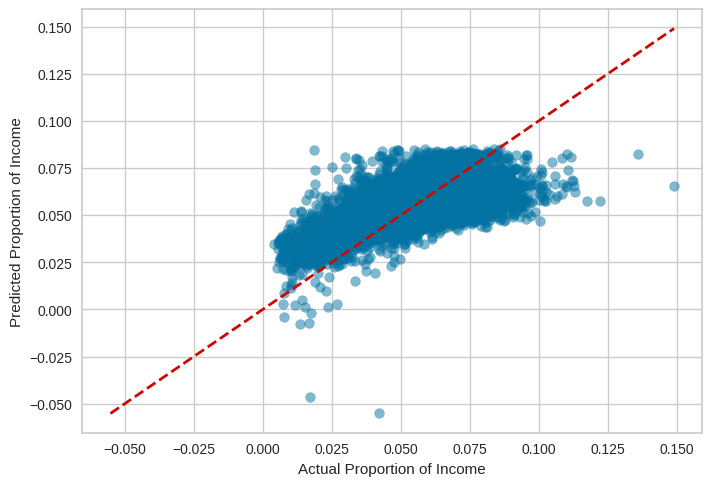

In [ ]:
plt.scatter(y_test, Y_test_pred, alpha = 0.5)
plt.xlabel("Actual Proportion of Income")
plt.ylabel("Predicted Proportion of Income")
min_val = min(y_test.min(), Y_test_pred.min())
max_val = max(y_test.max(), Y_test_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Ideal (y=x)')
plt.show()

In [ ]:
# Calculating residuals (validation data)
y_test_pred = elasNet_pipe_opt.predict(X_test)
residuals = y_test - y_test_pred

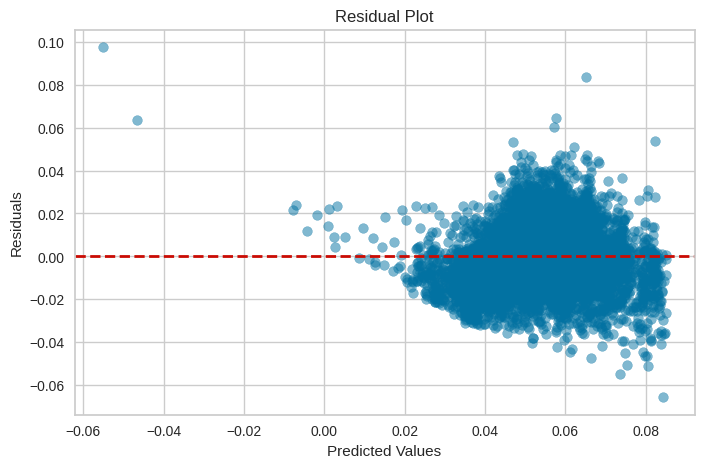

In [ ]:
# Residual plot (validation data)

plt.figure(figsize=(8, 5))
plt.scatter(y_test_pred, residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--', linewidth=2)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.grid(True)
plt.show()

In [ ]:
# Make predictions on the test set using the best model
y_test_pred = elasNet_pipe_opt.predict(X_test)

# Evaluate the model on the test set
mse = mean_squared_error(y_test, y_test_pred)
r2 = r2_score(y_test, y_test_pred)

print(f"  Mean Squared Error (MSE): {mse:.4f}")
print(f"  R-squared (R2 Score):   {r2:.4f}")

# Bootstrap confidence intervals for MSE and R^2

# Number of bootstrap iterations
n_bootstrap = 1000

# Lists to store the bootstrapped values
mse_bootstrap = []
r2_bootstrap = []

# For reproducibility
np.random.seed(2025)

# Do bootstrap resampling on the test set
for i in range(n_bootstrap):
    # Resampling w/ repl
    sample_indices = np.random.choice(len(y_test), size=len(y_test), replace=True)

    # Bootstrap samples for y_test and the predictions
    y_test_boot = y_test[sample_indices]
    y_pred_boot = y_test_pred[sample_indices]

    # Compute and store the performance scores for the current bootstrap sample
    mse_bootstrap.append(mean_squared_error(y_test_boot, y_pred_boot))
    r2_bootstrap.append(r2_score(y_test_boot, y_pred_boot))

# Convert the results to numpy arrays
mse_bootstrap = np.array(mse_bootstrap)
r2_bootstrap = np.array(r2_bootstrap)

# Calculate the 2.5th and 97.5th percentiles for the bootstrap distributions
mse_ci_lower, mse_ci_upper = np.percentile(mse_bootstrap, [2.5, 97.5])
r2_ci_lower, r2_ci_upper = np.percentile(r2_bootstrap, [2.5, 97.5])

# Report the bootstrap confidence intervals
print("\nBootstrap 95% Confidence Intervals:")
print(f"Mean Squared Error (MSE): [{mse_ci_lower:.4f}, {mse_ci_upper:.4f}]")
print(f"R-squared (R2 Score): [{r2_ci_lower:.4f}, {r2_ci_upper:.4f}]")

  Mean Squared Error (MSE): 0.0001
  R-squared (R2 Score):   0.4168

Bootstrap 95% Confidence Intervals:
Mean Squared Error (MSE): [0.0001, 0.0002]
R-squared (R2 Score): [0.4000, 0.4327]


Extract Elastic Net coefficients

In [ ]:
# Extract coefficients and intercept
coefficients = elasNet_pipe_opt.named_steps["elasNet_opt"].coef_
intercept = elasNet_pipe_opt.named_steps["elasNet_opt"].intercept_

# Create Series with feature names
coef_series = pd.Series(coefficients, index=X_train_pl.to_pandas().columns)

# Filter non-zero coefficients
non_zero_coefs = coef_series[coef_series != 0]

# Sort by absolute value (strongest effects first)
sorted_coefs_abs = non_zero_coefs.reindex(non_zero_coefs.abs().sort_values(ascending=False).index)

# print("Intercept:", intercept)
# print("Non-zero Coefficients:\n", non_zero_coefs)

Looking at the most important variables

In [ ]:
(
    sorted_coefs_abs.reset_index().rename(columns = {"index" : "Variable"})
    .merge(metadata_df, on = "Variable", how = "left")
    .head(20)
)

,Variable,0,Description
0,ECYMTNAVG,-0.008226,Average Maintainer Age
1,ECYHRIAVG,-0.001651,Average Household Income (Constant Year 2020 $)
2,ECYHRI300P,-0.001597,"Household Income $300,000 Or Over (Constant Ye..."
3,ECYHNIAVG,-0.001325,Average Household Income (Current Year $)
4,ECYMTN1524,-0.000953,Maintainers 15 To 24
5,ECYHRIX125,0.000863,"Household Income $100,000 To $124,999 (Constan..."
6,ECYHSZAVG,-0.000723,Average Number Of Persons In Private Households
7,ECYPTAAVG,-0.000684,Average Age Of Total Population
8,ECYINDPUBL,0.000678,91 Public Administration
9,ECYACTPR,0.000624,Participation Rate


## Define XGBoost Pipeline and Grid Search

Initialize the XGBoost regressor

In [ ]:
XGB_regressor = XGBRegressor(
    random_state=2025 # Seed for reproducibility
)

Set up a basic pipeline for XGBoost

In [ ]:
# Define a basic pipeline; just contains the regressor right now
xgb_pipeline = Pipeline(steps=[('regressor', XGB_regressor)])

Set up the hyperparameter search grid

In [ ]:
param_grid_xgb = {
    'regressor__n_estimators': [50, 100, 200, 300, 400],
    'regressor__learning_rate': [0.025, 0.05, 0.1, 0.15, 0.2],
    'regressor__max_depth': [1, 3, 5, 7, 9],
    # 'regressor__objective' : ['reg:squarederror', 'r2'],
    # 'regressor__subsample': [0.7, 0.9, 1.0],
    # 'regressor__colsample_bytree': [0.7, 0.9, 1.0],
    # 'regressor__gamma': [0, 1],
    # 'regressor__reg_alpha': [0, 1],
    # 'regressor__reg_lambda': [0, 1]
}

Set up the cross-validation parameters

In [ ]:
# Define cross-validation scheme
cv_object_xgb = KFold(n_splits = 5, shuffle = True, random_state = 2025)

Initialize the grid search object

In [ ]:
# Define GridSearchCV object
grid_search_xgb = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=param_grid_xgb,
    scoring='neg_mean_squared_error', # Or 'r2'
    cv=cv_object_xgb,
    n_jobs=-1,          # Use all cores for CV folds
    verbose=3,          # Show progress
    refit=True          # Refit the best model on the whole training set automatically
)

Run the grid search

In [ ]:
# Run GridSearchCV
grid_search_xgb.fit(X_train, y_train)

Fitting 5 folds for each of 125 candidates, totalling 625 fits


/usr/local/lib/python3.11/dist-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


## Save Model Results
- Export GridSearchCV object for future use.

In [ ]:
import pickle

# with open("D:\\Downloads\\2025-04-19_gridsearchcv_results_0009.pkl", 'wb') as f:
#     pickle.dump(grid_search_xgb, f)

with open("/content/drive/My Drive/DS3000/coursework_data/2025-04-20_gridsearchcv_results_0011.pkl", 'wb') as f:
    pickle.dump(grid_search_xgb, f)

Load the GridSearchCV result from a pickle file instead of re-running it

In [ ]:
# import pickle

# # Open the pickle file in binary read mode
# with open("D:\\Downloads\\2025-04-19_gridsearchcv_results_0009.pkl", 'rb') as file:
#     grid_search_xgb = pickle.load(file)

Save the best hyperparameters that were found

In [ ]:
# Save the best prarameters
best_params = grid_search_xgb.best_params_

Show the best hyperparameters found

In [ ]:
# Show best params found by GridSearchCV
print("\nBest parameters found by GridSearchCV:")
print(best_params)

## Train Final Model

In [ ]:
# Initialize a new XGBoost regressor using the best hyperparameters we found
final_xgb_model = XGBRegressor(
    n_estimators=best_params['regressor__n_estimators'],
    learning_rate=best_params['regressor__learning_rate'],
    max_depth=best_params['regressor__max_depth'],
    random_state=2025,
    n_jobs=2,
    verbosity=2
)

# Train the final model
final_xgb_model.fit(X_train, y_train)

Calculate residuals on the test set

In [ ]:
y_test_pred = final_xgb_model.predict(X_test)
residuals = y_test - y_test_pred

Create a residual plot

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(y_test_pred, residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--', linewidth=2)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.grid(True)
plt.show()

## Evaluate Final Model on Test Set

In [ ]:
# Make predictions on the test set using the best model
y_pred_test = final_xgb_model.predict(X_test)

In [ ]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

# Evaluate the model using regression metrics
mse = mean_squared_error(y_test, y_pred_test)
r2 = r2_score(y_test, y_pred_test)

print(f"\nModel Evaluation on Test Set:")
print(f"  Mean Squared Error (MSE): {mse:.4f}")
print(f"  R-squared (R2 Score):   {r2:.4f}")

## Visualize Predictions

In [ ]:
# Scatter plot of Actual vs Predicted values
plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred_test, alpha=0.5, edgecolor='k', s=50)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], '--r', linewidth=2, label='Theoretical Perfect Fit (y=x)') # Diagonal line for reference
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs. Predicted Target (XGBoost)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## Confidence Intervals via Bootstrapping
- Generate 95% confidence intervals for MSE and R².

In [ ]:
# Make predictions on the test set using the best model
y_pred_test = final_xgb_model.predict(X_test)

# Evaluate the model on the test set
mse = mean_squared_error(y_test, y_pred_test)
r2 = r2_score(y_test, y_pred_test)

print(f"  Mean Squared Error (MSE): {mse:.4f}")
print(f"  R-squared (R2 Score):   {r2:.4f}")

# Bootstrap confidence intervals for MSE and R^2

# Number of bootstrap iterations
n_bootstrap = 1000

# Lists to store the bootstrapped values
mse_bootstrap = []
r2_bootstrap = []

# For reproducibility
np.random.seed(2025)

# Do bootstrap resampling on the test set
for i in range(n_bootstrap):
    # Resampling w/ repl
    sample_indices = np.random.choice(len(y_test), size=len(y_test), replace=True)

    # Bootstrap samples for y_test and the predictions
    y_test_boot = y_test[sample_indices]
    y_pred_boot = y_pred_test[sample_indices]

    # Compute and store the performance scores for the current bootstrap sample
    mse_bootstrap.append(mean_squared_error(y_test_boot, y_pred_boot))
    r2_bootstrap.append(r2_score(y_test_boot, y_pred_boot))

# Convert the results to numpy arrays
mse_bootstrap = np.array(mse_bootstrap)
r2_bootstrap = np.array(r2_bootstrap)

# Calculate the 2.5th and 97.5th percentiles for the bootstrap distributions
mse_ci_lower, mse_ci_upper = np.percentile(mse_bootstrap, [2.5, 97.5])
r2_ci_lower, r2_ci_upper = np.percentile(r2_bootstrap, [2.5, 97.5])

# Report the bootstrap confidence intervals
print("\nBootstrap 95% Confidence Intervals:")
print(f"Mean Squared Error (MSE): [{mse_ci_lower:.4f}, {mse_ci_upper:.4f}]")
print(f"R-squared (R2 Score): [{r2_ci_lower:.4f}, {r2_ci_upper:.4f}]")


# Model Interpretability with SHAP

## Generate SHAP Values

In [ ]:
# Create a SHAP explainer for the XGBoost model
explainer = shap.TreeExplainer(final_xgb_model)

# Compute SHAP values for the test set
shap_values = explainer.shap_values(X_test)

## SHAP Summary Plot

In [ ]:
# Display a summary plot of feature importance
shap.summary_plot(shap_values, X_test)

## Enhanced SHAP Summary with Feature Descriptions

In [ ]:
# Make sure columns are named correctly
metadata_df.columns = ['Variable', 'Description']

# Create a dict for mapping variable names to their descriptions
var_to_desc = dict(zip(metadata_df['Variable'], metadata_df['Description']))

# Rename columns in X_test using the dictionary
# If a variable isn't in metadata, just use the original name
X_test_renamed = X_test.rename(columns=lambda col: var_to_desc.get(col, col))

# print(X_test_renamed.columns.tolist())

shap.summary_plot(shap_values, X_test_renamed, max_display=30)

## Rank Features by SHAP Contribution

In [ ]:
# # Calculate mean absolute SHAP values per feature
# mean_abs_shap = np.abs(shap_values).mean(axis=0)

# shap_importance_df = pd.DataFrame({
#     'Description': X_test_renamed.columns,
#     'Mean_Absolute_SHAP': mean_abs_shap
# }).sort_values(by='Mean_Absolute_SHAP', ascending=False)

# top_n = 30
# shap_top = shap_importance_df.head(top_n)
# print(shap_top)

# Mean SHAP values (not absolute)
mean_shap = shap_values.mean(axis=0)

# Mean absolute SHAP values
mean_abs_shap = np.abs(shap_values).mean(axis=0)

# Create a DataFrame to hold the results
shap_importance_df = pd.DataFrame({
    'Description': X_test_renamed.columns,
    'Mean_SHAP': mean_shap,
    'Mean_Absolute_SHAP': mean_abs_shap
})

# Sort for top absolute importance (regardless of direction)
top_30_abs = shap_importance_df.sort_values(by='Mean_Absolute_SHAP', ascending=False).head(30)

# Sort for top positive contribution
top_20_pos = shap_importance_df.sort_values(by='Mean_SHAP', ascending=False).head(20)

# Sort for top negative contribution
top_20_neg = shap_importance_df.sort_values(by='Mean_SHAP', ascending=True).head(20)

# Print results
print("\nTop 30 Most Important Features (by |mean SHAP|):")
print(top_30_abs)

print("\nTop 20 Positive SHAP Contributors:")
print(top_20_pos)

print("\nTop 20 Negative SHAP Contributors:")
print(top_20_neg)


## Dependence Plot for a chosen feature

In [ ]:
# Show a dependence plot for top feature
feature_name = 'ECYMTNAVG'
shap.dependence_plot(feature_name, shap_values, X_test)

In [ ]:
# Show a dependence plot for 2nd top feature
feature_name = 'ECYHNI200P'
shap.dependence_plot(feature_name, shap_values, X_test)

In [ ]:
# Show a dependence plot for 3rd top feature
feature_name = 'ECYINDPUBL'
shap.dependence_plot(feature_name, shap_values, X_test)

In [ ]:
# Show a dependence plot for 4th top feature
feature_name = 'ECYMTN6574'
shap.dependence_plot(feature_name, shap_values, X_test)

In [ ]:
# Show a dependence plot for 5th top feature
feature_name = 'ECYMTN7584'
shap.dependence_plot(feature_name, shap_values, X_test)